<a href="https://colab.research.google.com/github/Satshman/Prediccion_Precios_Renta/blob/main/ProyectoFinalModelosII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cargar el Dataset

En esta sección se realiza la descarga y carga del conjunto de datos utilizado para el proyecto.
El dataset corresponde a información de propiedades en renta en diferentes ciudades de India e incluye variables relacionadas con tamaño del inmueble, ubicación, número de habitaciones, estado de amueblado, entre otras características relevantes para la predicción del precio de alquiler.

El conjunto de datos es obtenido desde Kaggle utilizando la API oficial de Kaggle, lo que permite garantizar reproducibilidad en el experimento y facilitar futuras ejecuciones del notebook.

In [1]:
# Importación de librerías del sistema operativo
import os

# Configuración de la ruta donde se encuentra el archivo kaggle.json
# Este archivo contiene las credenciales necesarias para acceder a la API de Kaggle
os.environ['KAGGLE_CONFIG_DIR'] = '.'
!chmod 600 ./kaggle.json
!kaggle datasets download -d iamsouravbanerjee/house-rent-prediction-dataset
!unzip house-rent-prediction-dataset.zip > /dev/null
!wc *.csv

chmod: cannot access './kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset
License(s): other
100% 82.4k/82.4k [00:00<00:00, 45.0MB/s]

  4747  35669 566961 House_Rent_Dataset.csv


## Análisis exploratorio
El análisis exploratorio de datos (EDA) tiene como objetivo comprender la estructura y composición del conjunto de datos antes de entrenar los modelos de Machine Learning.

En esta etapa se analizan las características principales de las variables, la existencia de datos faltantes, la distribución de la variable objetivo y las posibles relaciones entre las variables predictoras y el precio de renta.

Además, este análisis permite identificar patrones, anomalías y comportamientos relevantes que pueden influir en el desempeño de los modelos predictivos.

In [2]:
# IMPORTACIÓN DE LIBRERÍAS
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual de las gráficas
sns.set(style="whitegrid")

In [3]:
# CARGA DEL DATASET

# Cargar el archivo CSV
df = pd.read_csv("House_Rent_Dataset.csv")

# Mostrar las primeras filas del dataset
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [4]:
# INFORMACIÓN GENERAL DEL DATASET

# Dimensiones del dataset
print("Forma del dataset:", df.shape)

# Tipos de datos de cada columna
print("\nTipos de datos:")
print(df.dtypes)

# Verificación de valores faltantes
print("\nValores faltantes:")
print(df.isnull().sum())

# Estadísticas descriptivas básicas
df.describe(include='all').T

Forma del dataset: (4746, 12)

Tipos de datos:
Posted On            object
BHK                   int64
Rent                  int64
Size                  int64
Floor                object
Area Type            object
Area Locality        object
City                 object
Furnishing Status    object
Tenant Preferred     object
Bathroom              int64
Point of Contact     object
dtype: object

Valores faltantes:
Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Posted On,4746,81,2022-07-06,311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BHK,4746.0,NaN,NaN,NaN,2.08386,0.832256,1.0,2.0,2.0,3.0,6.0
Rent,4746.0,NaN,NaN,NaN,34993.451327,78106.412937,1200.0,10000.0,16000.0,33000.0,3500000.0
Size,4746.0,NaN,NaN,NaN,967.490729,634.202328,10.0,550.0,850.0,1200.0,8000.0
Floor,4746,480,1 out of 2,379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Type,4746,3,Super Area,2446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Locality,4746,2235,Bandra West,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,4746,6,Mumbai,972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Furnishing Status,4746,3,Semi-Furnished,2251,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenant Preferred,4746,3,Bachelors/Family,3444,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Distribución del precio de renta

La variable objetivo del problema corresponde al precio de renta (Rent).
Analizar su distribución permite identificar:

concentración de valores,
posibles valores atípicos,
y el comportamiento general del mercado de alquiler.

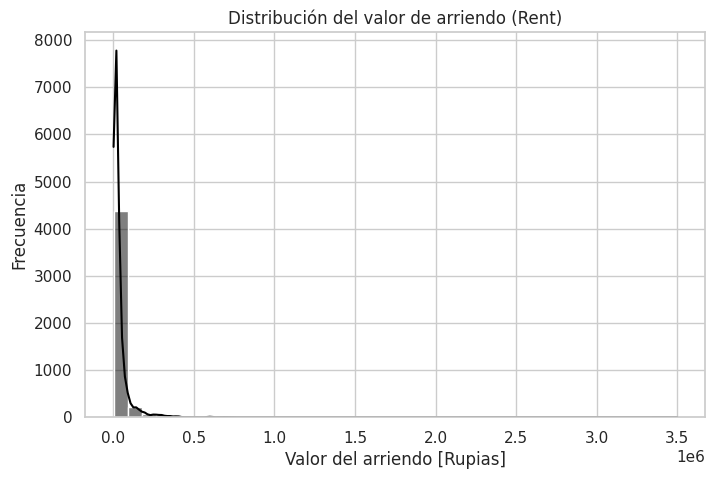

In [5]:
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO

# Histograma de la variable Rent
plt.figure(figsize=(8,5))

sns.histplot(
    df["Rent"],
    bins=40,
    kde=True,
    color='black'
)

plt.title("Distribución del valor de arriendo (Rent)")
plt.xlabel("Valor del arriendo [Rupias]")
plt.ylabel("Frecuencia")

plt.show()

Relación entre tamaño del inmueble y ciudad

Se analiza la relación entre el tamaño de la vivienda (Size) y la ciudad (City).
Esta visualización permite identificar si existe una relación directa entre ambas variables y observar posibles patrones lineales o no lineales.

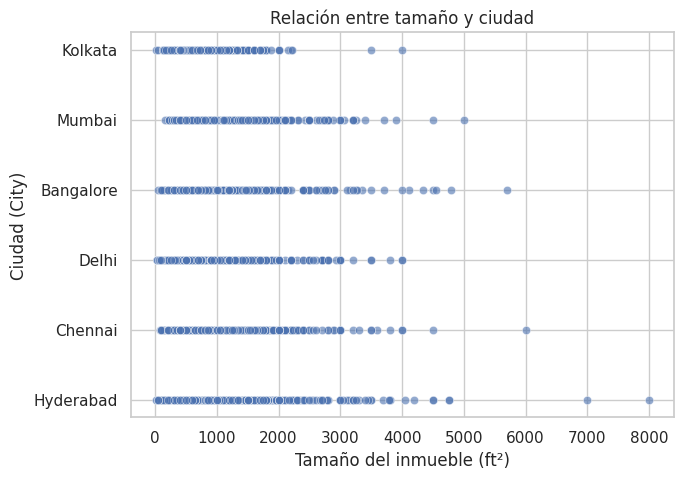

In [6]:
# RELACIÓN ENTRE TAMAÑO Y PRECIO

# Gráfica de dispersión entre tamaño y ciudad
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="Size",
    y="City",
    data=df,
    alpha=0.6
)

plt.title("Relación entre tamaño y ciudad")
plt.xlabel("Tamaño del inmueble (ft²)")
plt.ylabel("Ciudad (City)")

plt.show()

Distribución del precio de renta por ciudad

La ubicación geográfica puede influir significativamente en el precio de una propiedad.
Por esta razón, se analiza la distribución de los precios de renta en función de la ciudad mediante diagramas de caja (boxplots), los cuales permiten comparar medianas, dispersión y posibles valores atípicos.

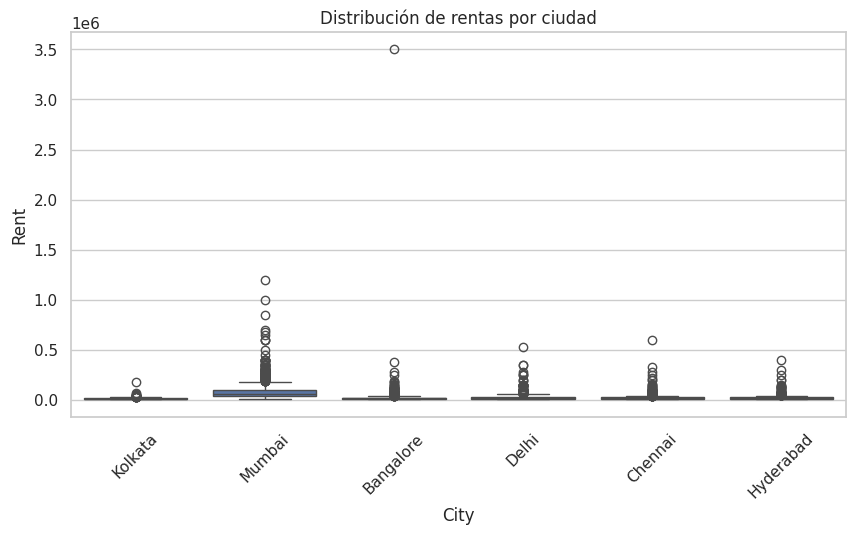

In [7]:
# DISTRIBUCIÓN DEL PRECIO POR CIUDAD


# Boxplot del precio de renta por ciudad
plt.figure(figsize=(10,5))

sns.boxplot(
    x="City",
    y="Rent",
    data=df
)

plt.title("Distribución de rentas por ciudad")

# Rotar etiquetas para mejor visualización
plt.xticks(rotation=45)

plt.show()

Correlación entre variables numéricas

El análisis de correlación permite identificar relaciones lineales entre las variables numéricas del dataset.

Esto ayuda a detectar:

variables altamente relacionadas,
posibles redundancias,
y características con mayor influencia sobre la variable objetivo.

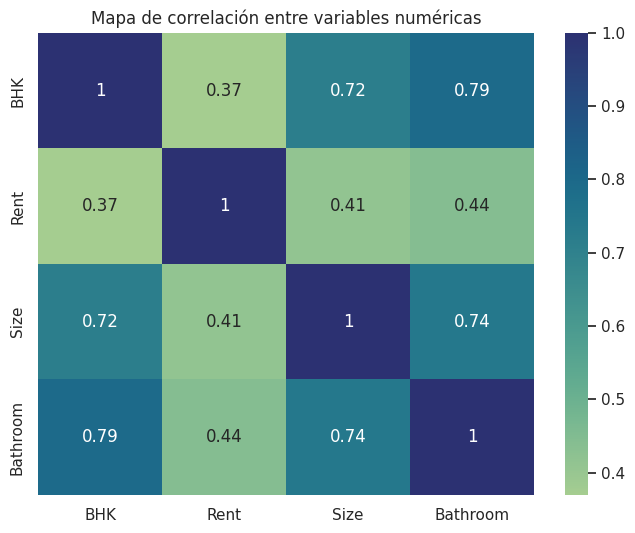

In [8]:
# CORRELACIÓN ENTRE VARIABLES NUMÉRICAS

# Matriz de correlación
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="crest"
)

plt.title("Mapa de correlación entre variables numéricas")

plt.show()

Valores atipicos

Text(0.5, 0, 'Valor del arriendo')

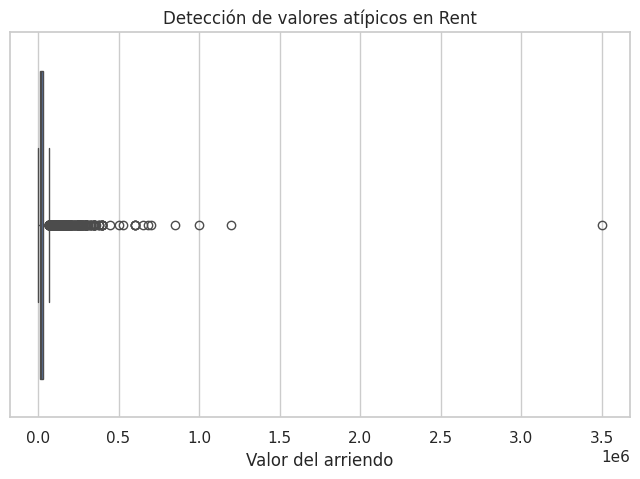

In [9]:
# DETECCIÓN DE VALORES ATÍPICOS

plt.figure(figsize=(8,5))

sns.boxplot(x=df["Rent"])

plt.title("Detección de valores atípicos en Rent")

plt.xlabel("Valor del arriendo")


# Limpieza de datos
Antes de entrenar los modelos de Machine Learning, es necesario realizar un proceso de limpieza y transformación de los datos con el fin de garantizar que la información pueda ser utilizada correctamente por los algoritmos de aprendizaje.

En esta etapa se realizan tareas como:

normalización de variables de texto,
transformación de variables compuestas,
manejo de variables categóricas,
generación de nuevas características,
y preparación final del conjunto de datos para el entrenamiento.

Estas transformaciones permiten reducir inconsistencias, mejorar la calidad de los datos y facilitar el aprendizaje de los modelos predictivos.

Creación de una copia del dataset

Se crea una copia del dataset original con el fin de preservar los datos iniciales y evitar modificaciones accidentales durante el proceso de limpieza y transformación.

In [10]:
# COPIA DEL DATASET ORIGINAL

# Crear copia del dataset
data = df.copy()

# Visualizar información general
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


Normalización de variables categóricas

Las variables de texto pueden contener inconsistencias como:

mayúsculas y minúsculas,
espacios innecesarios,
o diferencias de escritura.

Por esta razón, se realiza una normalización básica para uniformar el formato de las variables categóricas.

In [11]:
# NORMALIZACIÓN DE VARIABLES DE TEXTO

# Limpiar columnas de texto
for col in data.select_dtypes(include='object').columns:

    # Convertir a texto, eliminar espacios y pasar a minúsculas
    data[col] = (
        data[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

# Revisar valores únicos de variables categóricas
for col in data.select_dtypes(include='object').columns:

    print(f"\n{col}:")
    print(data[col].unique()[:10])


Posted On:
['2022-05-18' '2022-05-13' '2022-05-16' '2022-07-04' '2022-05-09'
 '2022-04-29' '2022-06-21' '2022-06-07' '2022-06-20' '2022-05-23']

Floor:
['ground out of 2' '1 out of 3' '1 out of 2' 'ground out of 1'
 'ground out of 4' '1 out of 4' '1 out of 1' 'ground out of 3'
 '2 out of 3' '4 out of 5']

Area Type:
['super area' 'carpet area' 'built area']

Area Locality:
['bandel' 'phool bagan, kankurgachi' 'salt lake city sector 2'
 'dumdum park' 'south dum dum' 'thakurpukur' 'malancha'
 'palm avenue kolkata, ballygunge' 'natunhat'
 'action area 1, rajarhat newtown']

City:
['kolkata' 'mumbai' 'bangalore' 'delhi' 'chennai' 'hyderabad']

Furnishing Status:
['unfurnished' 'semi-furnished' 'furnished']

Tenant Preferred:
['bachelors/family' 'bachelors' 'family']

Point of Contact:
['contact owner' 'contact agent' 'contact builder']


Transformación de la variable Floor

La columna Floor contiene información compuesta en formato textual, por ejemplo:

"1 out of 5"
"Ground out of 2"

Este formato no puede ser utilizado directamente por los modelos de Machine Learning. Por esta razón, la variable se divide en dos nuevas características numéricas:

piso actual del inmueble,
número total de pisos del edificio.

In [12]:
# TRANSFORMACIÓN DE LA VARIABLE FLOOR

# Función para separar piso actual y total de pisos
def parse_floor(value):

    try:

        # Separar texto usando "out of"
        parts = value.split(" out of ")

        current = parts[0].strip().lower()

        total = (
            parts[1].strip().lower()
            if len(parts) > 1 else current
        )

        # Casos especiales
        if current == "ground":
            current = 0

        elif current == "upper basement":
            current = -1

        elif current == "lower basement":
            current = -2

        else:
            current = int(current)

        # Procesamiento del total de pisos
        if total == "ground":
            total = 0

        total = np.nan if pd.isna(total) else int(total)

        return pd.Series([current, total])

    except:
        return pd.Series([np.nan, np.nan])

# Crear nuevas columnas numéricas
data[["Current_Floor", "Total_Floors"]] = (
    data["Floor"].apply(parse_floor)
)

# Eliminar columna original
data.drop(columns=["Floor"], inplace=True)

Extracción de información temporal

La columna Posted On contiene fechas de publicación de las propiedades.

En lugar de utilizar la fecha completa, se extraen características temporales más simples como:

día,
mes.

Esto permite representar la información temporal de manera numérica.

In [13]:
# TRANSFORMACIÓN DE VARIABLES TEMPORALES

# Convertir columna a formato fecha
data["Posted On"] = pd.to_datetime(data["Posted On"])

# Extraer día y mes
data["Posted_Day"] = data["Posted On"].dt.day
data["Posted_Month"] = data["Posted On"].dt.month

# Eliminar columna original
data.drop(columns=["Posted On"], inplace=True)

Codificación de variables categóricas

Los algoritmos de Machine Learning requieren variables numéricas para poder realizar el entrenamiento.

Por esta razón, las variables categóricas son transformadas mediante One-Hot Encoding, generando columnas binarias para cada categoría.

In [14]:
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS

# Variables categóricas seleccionadas
cat_cols = [
    'Area Type',
    'City',
    'Furnishing Status',
    'Tenant Preferred',
    'Point of Contact'
]

# Aplicar One-Hot Encoding
data = pd.get_dummies(
    data,
    columns=cat_cols,
    drop_first=False
)

Reducción de cardinalidad en Area Locality

La variable Area Locality contiene una gran cantidad de categorías diferentes, lo que puede aumentar excesivamente la dimensionalidad del dataset.

Para controlar este problema:

se conservan únicamente las localidades más frecuentes,
y las localidades poco comunes se agrupan en una categoría general.

In [15]:
# REDUCCIÓN DE CARDINALIDAD EN AREA LOCALITY


# Frecuencia de localidades
locality_counts = data["Area Locality"].value_counts()

# Estadísticas descriptivas
locality_counts.describe()

# Umbral mínimo de frecuencia
threshold = 20

# Localidades frecuentes
frequent_localities = (
    locality_counts[locality_counts >= threshold].index
)

# Crear variables binarias
for loc in frequent_localities:

    data[f"Locality_{loc}"] = (
        data["Area Locality"] == loc
    ).astype(int)

# Agrupar localidades poco frecuentes
data["Locality_Rare"] = (
    ~data["Area Locality"].isin(frequent_localities)
).astype(int)

# Eliminar columna original
data.drop(columns=["Area Locality"], inplace=True)

Verificación del conjunto de datos procesado

Finalmente, se verifica el estado del dataset después del proceso de limpieza y transformación, revisando:

valores faltantes,
tipos de datos,
dimensiones,
y estructura final de las variables.

In [16]:
# VERIFICACIÓN FINAL DEL DATASET


# Revisar valores faltantes
print("Valores faltantes por columna:\n")

print(data.isnull().sum())

# Información general
data.info()

# Primeras filas
data.head()

Valores faltantes por columna:

BHK                                  0
Rent                                 0
Size                                 0
Bathroom                             0
Current_Floor                        0
Total_Floors                         0
Posted_Day                           0
Posted_Month                         0
Area Type_built area                 0
Area Type_carpet area                0
Area Type_super area                 0
City_bangalore                       0
City_chennai                         0
City_delhi                           0
City_hyderabad                       0
City_kolkata                         0
City_mumbai                          0
Furnishing Status_furnished          0
Furnishing Status_semi-furnished     0
Furnishing Status_unfurnished        0
Tenant Preferred_bachelors           0
Tenant Preferred_bachelors/family    0
Tenant Preferred_family              0
Point of Contact_contact agent       0
Point of Contact_contact builder

,BHK,Rent,Size,Bathroom,Current_Floor,Total_Floors,Posted_Day,Posted_Month,Area Type_built area,Area Type_carpet area,...,Point of Contact_contact agent,Point of Contact_contact builder,Point of Contact_contact owner,Locality_bandra west,Locality_gachibowli,Locality_electronic city,"Locality_miyapur, nh 9",Locality_velachery,Locality_madipakkam,Locality_Rare
0,2,10000,1100,2,0,2,18,5,False,False,...,False,False,True,0,0,0,0,0,0,1
1,2,20000,800,1,1,3,13,5,False,False,...,False,False,True,0,0,0,0,0,0,1
2,2,17000,1000,1,1,3,16,5,False,False,...,False,False,True,0,0,0,0,0,0,1
3,2,10000,800,1,1,2,4,7,False,False,...,False,False,True,0,0,0,0,0,0,1
4,2,7500,850,1,1,2,9,5,False,True,...,False,False,True,0,0,0,0,0,0,1


Separación de variables predictoras y variable objetivo

Se separan las variables de entrada (X) y la variable objetivo (y) para preparar el dataset antes del entrenamiento de los modelos de Machine Learning.

In [17]:
# SEPARACIÓN DE VARIABLES


# Variable objetivo
y = data["Rent"]

# Variables predictoras
X = data.drop(columns=["Rent"])

# Dimensiones finales
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (4746, 32)
Shape de y: (4746,)


# Entrenamiento de los Modelos

Entrenamiento y evaluación de modelos

En esta etapa se entrenan distintos modelos de Machine Learning con el objetivo de predecir el valor de renta de viviendas utilizando las características disponibles en el dataset.

Debido a que el problema consiste en estimar un valor numérico continuo, se aborda como una tarea de regresión supervisada.

Los modelos evaluados fueron:

Regresión Lineal
Árbol de Decisión
K-Nearest Neighbors (KNN)
Support Vector Regression (SVR)
XGBoost Regressor

Para evaluar el desempeño de los modelos se utilizaron métricas de regresión como:

MAE (Mean Absolute Error),
RMSE (Root Mean Squared Error),
validación cruzada,
e intervalos de confianza al 95%.

##División y escalamiento de los datos

El conjunto de datos se divide en subconjuntos de entrenamiento y prueba para evaluar la capacidad de generalización de los modelos sobre datos no vistos.

Posteriormente, se aplica estandarización a las variables predictoras utilizando StandardScaler, ya que algunos modelos son sensibles a la escala de los datos.

In [18]:
# PREPARACIÓN DE LOS DATOS

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# División train / test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Escalamiento de variables

# Crear scaler
scaler_X = StandardScaler()

# Ajustar scaler usando únicamente datos de entrenamiento
X_train_scaled = scaler_X.fit_transform(X_train)

# Transformar datos de prueba
X_test_scaled = scaler_X.transform(X_test)

# Convertir variables objetivo a arrays unidimensionales
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

##Intervalos de confianza

Además de calcular métricas promedio, se estiman intervalos de confianza al 95% para evaluar la estabilidad y variabilidad del desempeño de los modelos durante la validación cruzada.

In [19]:
# INTERVALOS DE CONFIANZA

import numpy as np
import scipy.stats as st

# Función para calcular intervalo de confianza del 95%
def intervalo_confianza_95(valores):

    valores = np.array(valores)

    # Media de las métricas
    mean = np.mean(valores)

    # Error estándar de la media
    sem = st.sem(valores)

    # Intervalo de confianza
    ci = st.t.interval(
        confidence=0.95,
        df=len(valores)-1,
        loc=mean,
        scale=sem
    )

    return mean, ci

##Regresión Lineal

La Regresión Lineal se utiliza como modelo base debido a su simplicidad e interpretabilidad. Este modelo busca establecer una relación lineal entre las variables predictoras y el valor de renta.

Para evaluar su desempeño se utiliza validación cruzada con 5 particiones (K-Fold Cross Validation).

In [20]:
# REGRESIÓN LINEAL

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de validación cruzada

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Listas para almacenar métricas

mae_folds = []
rmse_folds = []
r2_folds = []


# ============================================================
# VALIDACIÓN CRUZADA
# ============================================================

for train_index, val_index in kf.split(X_train_scaled):

    # Separar folds de entrenamiento y validación
    X_tr = X_train_scaled[train_index]
    X_val = X_train_scaled[val_index]

    y_tr = y_train[train_index]
    y_val = y_train[val_index]

    # --------------------------------------------------------
    # Crear modelo
    # --------------------------------------------------------

    model = LinearRegression()

    # --------------------------------------------------------
    # Entrenar modelo
    # --------------------------------------------------------

    model.fit(X_tr, y_tr)

    # --------------------------------------------------------
    # Realizar predicciones
    # --------------------------------------------------------

    preds = model.predict(X_val)

    # --------------------------------------------------------
    # Calcular métricas
    # --------------------------------------------------------

    mae = mean_absolute_error(y_val, preds)

    rmse = np.sqrt(
        mean_squared_error(y_val, preds)
    )

    r2 = r2_score(y_val, preds)

    # --------------------------------------------------------
    # Guardar métricas
    # --------------------------------------------------------

    mae_folds.append(mae)
    rmse_folds.append(rmse)
    r2_folds.append(r2)

# ============================================================
# RESULTADOS PROMEDIO DE VALIDACIÓN CRUZADA
# ============================================================

print("RESULTADOS VALIDACIÓN CRUZADA")
print("-" * 40)

print("MAE promedio CV:", np.mean(mae_folds))
print("RMSE promedio CV:", np.mean(rmse_folds))
print("R² promedio CV:", np.mean(r2_folds))

RESULTADOS VALIDACIÓN CRUZADA
----------------------------------------
MAE promedio CV: 22002.719279767512
RMSE promedio CV: 59636.34300777239
R² promedio CV: 0.4277624109902992


Evaluación estadística del modelo

Se calculan intervalos de confianza al 95% para las métricas obtenidas durante la validación cruzada, con el fin de estimar la estabilidad del desempeño del modelo.

In [21]:
# ============================================================
# INTERVALOS DE CONFIANZA
# ============================================================

# Calcular intervalos de confianza
mae_mean, mae_ci = intervalo_confianza_95(mae_folds)

rmse_mean, rmse_ci = intervalo_confianza_95(rmse_folds)

r2_mean, r2_ci = intervalo_confianza_95(r2_folds)

# Mostrar resultados
print("\nINTERVALOS DE CONFIANZA (95%)")
print("-" * 40)

print("MAE promedio:", mae_mean)
print("IC95% MAE:", mae_ci)

print("\nRMSE promedio:", rmse_mean)
print("IC95% RMSE:", rmse_ci)

print("\nR² promedio:", r2_mean)
print("IC95% R²:", r2_ci)


INTERVALOS DE CONFIANZA (95%)
----------------------------------------
MAE promedio: 22002.719279767512
IC95% MAE: (np.float64(20738.86848970913), np.float64(23266.570069825895))

RMSE promedio: 59636.34300777239
IC95% RMSE: (np.float64(12075.797753603569), np.float64(107196.8882619412))

R² promedio: 0.4277624109902992
IC95% R²: (np.float64(0.20001558101249536), np.float64(0.655509240968103))


Evaluación final del modelo

Finalmente, el modelo se entrena utilizando todo el conjunto de entrenamiento y posteriormente se evalúa sobre el conjunto de prueba para medir su capacidad de generalización.

In [22]:
# ============================================================
# ENTRENAMIENTO FINAL DEL MODELO
# ============================================================

# Crear modelo final
model_final = LinearRegression()

# Entrenar usando todos los datos de entrenamiento
model_final.fit(X_train_scaled, y_train)

# ============================================================
# PREDICCIONES SOBRE TEST
# ============================================================

y_pred_lr = model_final.predict(X_test_scaled)

# ============================================================
# MÉTRICAS FINALES
# ============================================================

mae_test = mean_absolute_error(y_test, y_pred_lr)

rmse_test = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_test = r2_score(y_test, y_pred_lr)

# ============================================================
# RESULTADOS FINALES
# ============================================================

print("\nRESULTADOS SOBRE TEST")
print("-" * 40)

print("MAE Test:", mae_test)
print("RMSE Test:", rmse_test)
print("R² Test:", r2_test)


RESULTADOS SOBRE TEST
----------------------------------------
MAE Test: 20923.399306981257
RMSE Test: 42633.57724896763
R² Test: 0.5439277287692712


COMPARACIÓN VALORES REALES VS PREDICHOS

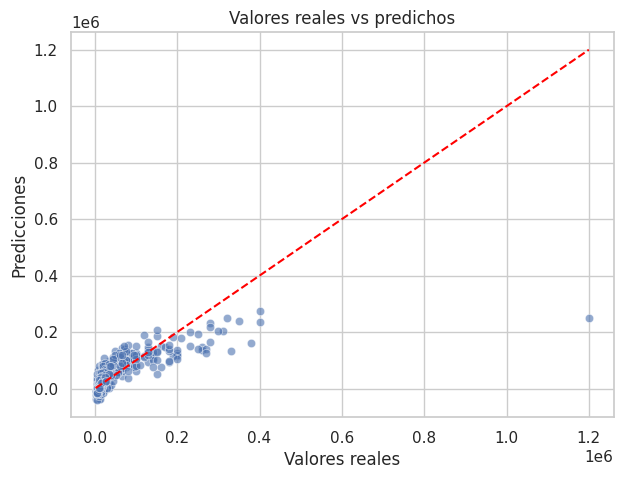

In [23]:
# ============================================================
# COMPARACIÓN VALORES REALES VS PREDICHOS
# ============================================================

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_test,
    y=y_pred_lr,
    alpha=0.6
)

# Línea ideal de predicción perfecta
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title("Valores reales vs predichos")

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")

plt.show()

ANÁLISIS DE RESIDUOS
El análisis de residuos permite evaluar los errores cometidos por el modelo durante la predicción.

Los residuos corresponden a la diferencia entre los valores reales y los valores predichos:

Residuo=y
real−ypredicho
	​


Este análisis ayuda a identificar:

posibles sesgos en el modelo,
presencia de valores atípicos,
y el comportamiento general de los errores de predicción.

Idealmente, los residuos deberían distribuirse de manera cercana a una distribución normal y centrarse alrededor de cero.

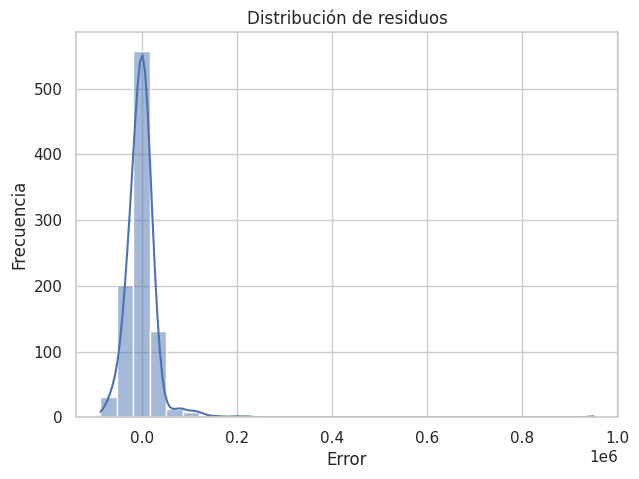

,Modelo,MAE,RMSE,R2
0,Linear Regression,20923.399307,42633.577249,0.543928


In [24]:
# ============================================================
# ANÁLISIS DE RESIDUOS
# ============================================================

# Calcular residuos
residuos = y_test - y_pred_lr

plt.figure(figsize=(7,5))

sns.histplot(
    residuos,
    bins=30,
    kde=True
)

plt.title("Distribución de residuos")

plt.xlabel("Error")

plt.ylabel("Frecuencia")

plt.show()

# ============================================================
# GUARDAR RESULTADOS DEL MODELO
# ============================================================

# Crear lista si no existe
try:
    resultados_modelos
except NameError:
    resultados_modelos = []

# Guardar métricas
resultados_modelos.append({
    "Modelo": "Linear Regression",
    "MAE": mae_test,
    "RMSE": rmse_test,
    "R2": r2_test
})

# Mostrar resultados almacenados
pd.DataFrame(resultados_modelos)

## Árbol de Decisión
El modelo de Árbol de Decisión es un algoritmo no paramétrico capaz de capturar relaciones no lineales entre las variables predictoras y la variable objetivo.

Este modelo funciona dividiendo recursivamente el conjunto de datos mediante reglas de decisión que buscan minimizar el error de predicción dentro de cada partición.

A diferencia de la Regresión Lineal, los árboles de decisión pueden adaptarse a comportamientos complejos del mercado inmobiliario sin asumir relaciones lineales entre las variables.

Para optimizar el desempeño del modelo, se utiliza búsqueda de hiperparámetros mediante GridSearchCV, evaluando diferentes configuraciones del árbol mediante validación cruzada.

In [25]:
# ============================================================
# ÁRBOL DE DECISIÓN
# ============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# DEFINICIÓN DE HIPERPARÁMETROS
# ============================================================

# Configuración de hiperparámetros a evaluar
param_grid = {

    'max_depth': [None, 5, 10, 20, 30, 50],

    'min_samples_split': [2, 5, 10, 20],

    'min_samples_leaf': [1, 2, 4, 10],

    'max_features': [None, 'sqrt', 'log2'],

    'criterion': [
        'squared_error',
        'absolute_error'
    ]
}

# ============================================================
# GRID SEARCH CON VALIDACIÓN CRUZADA
# ============================================================

grid_dt = GridSearchCV(

    estimator=DecisionTreeRegressor(
        random_state=100
    ),

    param_grid=param_grid,

    scoring='neg_mean_absolute_error',

    cv=5,

    n_jobs=-1,

    verbose=1
)

# ============================================================
# ENTRENAMIENTO DEL MODELO
# ============================================================

grid_dt.fit(X_train, y_train)

# ============================================================
# MEJORES HIPERPARÁMETROS
# ============================================================

print("Mejores hiperparámetros encontrados:")
print(grid_dt.best_params_)

# Obtener mejor modelo
best_dt = grid_dt.best_estimator_

# ============================================================
# PREDICCIONES SOBRE TEST
# ============================================================

y_pred_dt = best_dt.predict(X_test)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Mejores hiperparámetros encontrados:
{'criterion': 'absolute_error', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 20}


MÉTRICAS FINALES

In [26]:
# ============================================================
# MÉTRICAS FINALES
# ============================================================

mae_final = mean_absolute_error(
    y_test,
    y_pred_dt
)

rmse_final = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_dt
    )
)

r2_final = r2_score(
    y_test,
    y_pred_dt
)


# ============================================================
# RESULTADOS FINALES
# ============================================================

print("\nRESULTADOS SOBRE TEST")
print("-" * 40)

print(f"MAE final: {mae_final}")

print(f"RMSE final: {rmse_final}")

print(f"R² final: {r2_final}")


RESULTADOS SOBRE TEST
----------------------------------------
MAE final: 11901.488421052632
RMSE final: 33457.648806112455
R² final: 0.7191199098541585


INTERVALOS DE CONFIANZA

In [27]:
# ============================================================
# INTERVALOS DE CONFIANZA
# ============================================================

# Extraer MAE de cada fold
mae_folds_dt = [

    -grid_dt.cv_results_[f"split{i}_test_score"][
        grid_dt.best_index_
    ]

    for i in range(5)
]

# Calcular intervalo de confianza
mae_mean_dt, mae_ci_dt = (
    intervalo_confianza_95(mae_folds_dt)
)

# Mostrar resultados
print("\nINTERVALOS DE CONFIANZA")
print("-" * 40)

print("Árbol de decisión - MAE promedio:", mae_mean_dt)

print("Árbol de decisión - IC95% MAE:", mae_ci_dt)


INTERVALOS DE CONFIANZA
----------------------------------------
Árbol de decisión - MAE promedio: 12699.96051192705
Árbol de decisión - IC95% MAE: (np.float64(9815.955825062356), np.float64(15583.965198791746))


VALORES REALES VS PREDICHOS

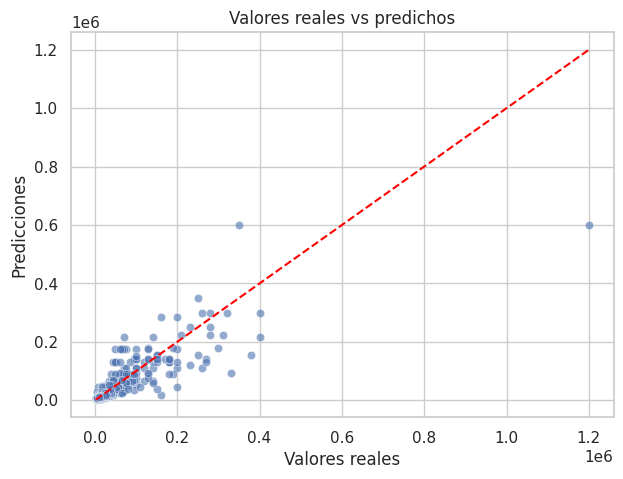

In [28]:
# ============================================================
# VALORES REALES VS PREDICHOS
# ============================================================

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_test,
    y=y_pred_dt,
    alpha=0.6
)

# Línea ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title("Valores reales vs predichos")

plt.xlabel("Valores reales")

plt.ylabel("Predicciones")

plt.show()

ANÁLISIS DE RESIDUOS

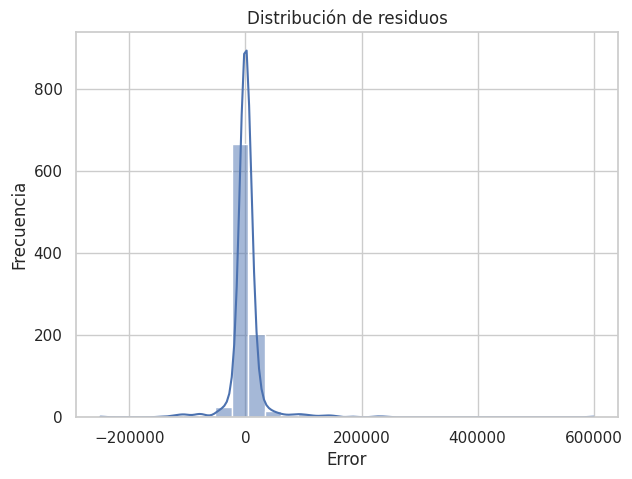

In [29]:
# ============================================================
# ANÁLISIS DE RESIDUOS
# ============================================================

# Calcular residuos
residuos_dt = y_test - y_pred_dt

plt.figure(figsize=(7,5))

sns.histplot(
    residuos_dt,
    bins=30,
    kde=True
)

plt.title("Distribución de residuos")

plt.xlabel("Error")

plt.ylabel("Frecuencia")

plt.show()


IMPORTANCIA DE VARIABLES

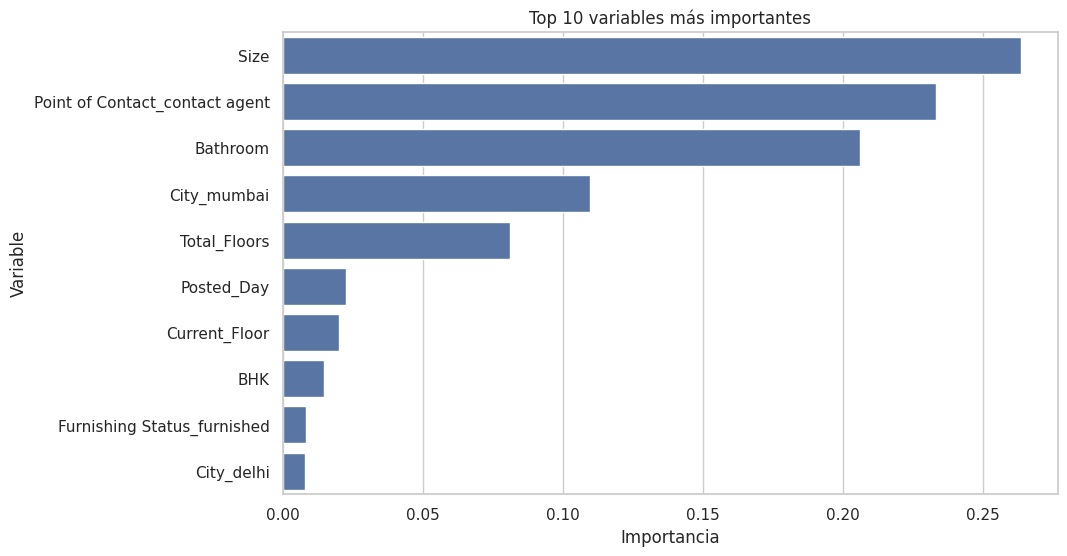

,Modelo,MAE,RMSE,R2
0,Linear Regression,20923.399307,42633.577249,0.543928
1,Decision Tree,11901.488421,33457.648806,0.719120


In [30]:
# ============================================================
# IMPORTANCIA DE VARIABLES
# ============================================================

# Obtener importancia de variables
importancias = pd.DataFrame({

    "Variable": X_train.columns,

    "Importancia": best_dt.feature_importances_

})

# Ordenar variables
importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

# Mostrar top 10
plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias.head(10),
    x="Importancia",
    y="Variable"
)

plt.title("Top 10 variables más importantes")

plt.show()

# ============================================================
# GUARDAR RESULTADOS
# ============================================================

# Crear lista si no existe
try:
    resultados_modelos
except NameError:
    resultados_modelos = []

# Guardar métricas
resultados_modelos.append({

    "Modelo": "Decision Tree",

    "MAE": mae_final,

    "RMSE": rmse_final,

    "R2": r2_final
})

# Mostrar tabla acumulada
pd.DataFrame(resultados_modelos)

##K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) es un algoritmo basado en distancia que realiza predicciones utilizando las observaciones más cercanas dentro del espacio de características.

En problemas de regresión, el modelo estima el valor objetivo calculando el promedio de los vecinos más próximos al nuevo dato.

Debido a que KNN depende directamente de distancias entre observaciones, es necesario aplicar escalamiento a las variables predictoras antes del entrenamiento.

Para optimizar el desempeño del modelo, se realiza búsqueda de hiperparámetros mediante GridSearchCV, evaluando diferentes configuraciones del número de vecinos, tipo de ponderación y métricas de distancia.

In [31]:
# ============================================================
# K-NEAREST NEIGHBORS (KNN)
# ============================================================

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    make_scorer,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# DEFINICIÓN DE HIPERPARÁMETROS
# ============================================================

param_grid = {

    'n_neighbors': list(range(1, 50)),

    'weights': [
        'uniform',
        'distance'
    ],

    'metric': [
        'euclidean',
        'manhattan'
    ]
}

# ============================================================
# MÉTRICA DE EVALUACIÓN
# ============================================================

# MAE negativo para GridSearchCV
mae_scorer = make_scorer(
    mean_absolute_error,
    greater_is_better=False
)

# ============================================================
# GRID SEARCH CON VALIDACIÓN CRUZADA
# ============================================================

grid_knn = GridSearchCV(

    estimator=KNeighborsRegressor(),

    param_grid=param_grid,

    scoring=mae_scorer,

    cv=5,

    n_jobs=-1,

    verbose=1
)

# ============================================================
# ENTRENAMIENTO DEL MODELO
# ============================================================

grid_knn.fit(X_train_scaled, y_train)

# ============================================================
# MEJORES HIPERPARÁMETROS
# ============================================================

print("Mejores hiperparámetros:")

print(grid_knn.best_params_)

# ============================================================
# INTERVALOS DE CONFIANZA
# ============================================================

# Extraer MAE de cada fold
mae_folds_knn = [

    -grid_knn.cv_results_[f"split{i}_test_score"][
        grid_knn.best_index_
    ]

    for i in range(5)
]

# Calcular intervalo de confianza
mae_mean_knn, mae_ci_knn = (
    intervalo_confianza_95(mae_folds_knn)
)

# Mostrar resultados
print("\nINTERVALOS DE CONFIANZA")
print("-" * 40)

print("KNN - MAE promedio:", mae_mean_knn)

print("KNN - IC95% MAE:", mae_ci_knn)

# ============================================================
# MEJOR MODELO
# ============================================================

best_knn = grid_knn.best_estimator_

# ============================================================
# PREDICCIONES SOBRE TEST
# ============================================================

y_pred_knn = best_knn.predict(X_test_scaled)

Fitting 5 folds for each of 196 candidates, totalling 980 fits
Mejores hiperparámetros:
{'metric': 'manhattan', 'n_neighbors': 37, 'weights': 'distance'}

INTERVALOS DE CONFIANZA
----------------------------------------
KNN - MAE promedio: 14249.995815909922
KNN - IC95% MAE: (np.float64(10912.900997002935), np.float64(17587.090634816912))


MÉTRICAS FINALES

In [32]:
# ============================================================
# MÉTRICAS FINALES
# ============================================================

final_mae_knn = mean_absolute_error(
    y_test,
    y_pred_knn
)

final_rmse_knn = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_knn
    )
)

final_r2_knn = r2_score(
    y_test,
    y_pred_knn
)

# ============================================================
# RESULTADOS FINALES
# ============================================================

print("\nRESULTADOS SOBRE TEST")
print("-" * 40)

print("MAE final:", final_mae_knn)

print("RMSE final:", final_rmse_knn)

print("R² final:", final_r2_knn)


RESULTADOS SOBRE TEST
----------------------------------------
MAE final: 13798.869157959383
RMSE final: 42808.96940942702
R² final: 0.5401674981511888


VALORES REALES VS PREDICHOS

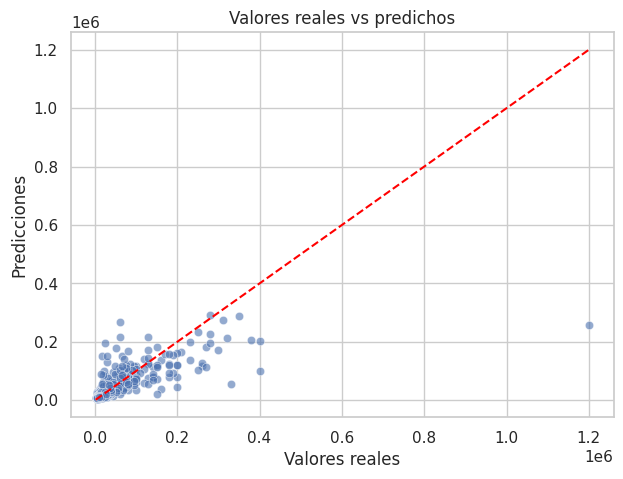

In [33]:
# ============================================================
# VALORES REALES VS PREDICHOS
# ============================================================

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_test,
    y=y_pred_knn,
    alpha=0.6
)

# Línea ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title("Valores reales vs predichos")

plt.xlabel("Valores reales")

plt.ylabel("Predicciones")

plt.show()

ANÁLISIS DE RESIDUOS

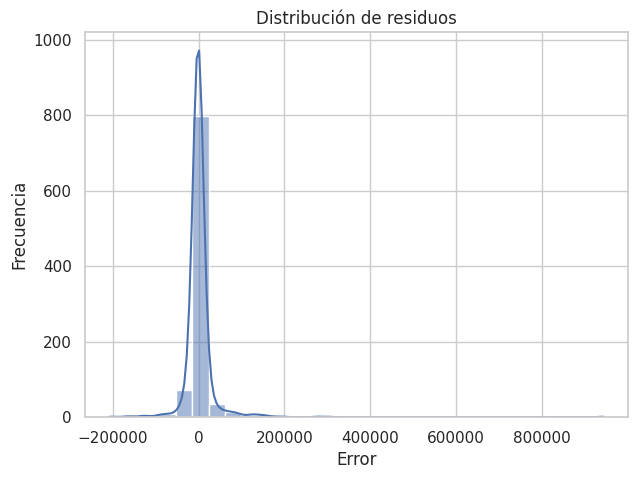

,Modelo,MAE,RMSE,R2
0,Linear Regression,20923.399307,42633.577249,0.543928
1,Decision Tree,11901.488421,33457.648806,0.719120
2,KNN,13798.869158,42808.969409,0.540167


In [34]:
# ============================================================
# ANÁLISIS DE RESIDUOS
# ============================================================

# Calcular residuos
residuos_knn = y_test - y_pred_knn

plt.figure(figsize=(7,5))

sns.histplot(
    residuos_knn,
    bins=30,
    kde=True
)

plt.title("Distribución de residuos")

plt.xlabel("Error")

plt.ylabel("Frecuencia")

plt.show()

# ============================================================
# GUARDAR RESULTADOS
# ============================================================

# Crear lista si no existe
try:
    resultados_modelos
except NameError:
    resultados_modelos = []

# Guardar métricas
resultados_modelos.append({

    "Modelo": "KNN",

    "MAE": final_mae_knn,

    "RMSE": final_rmse_knn,

    "R2": final_r2_knn
})

# Mostrar tabla acumulada
pd.DataFrame(resultados_modelos)

## Support Vector Machine

Support Vector Regression (SVR) es una extensión de las Máquinas de Vectores de Soporte aplicada a problemas de regresión.

Este modelo busca encontrar una función capaz de aproximar los datos minimizando el error de predicción dentro de un margen de tolerancia definido.

A diferencia de modelos lineales tradicionales, SVR puede capturar relaciones no lineales mediante el uso de funciones kernel. En este caso, se utiliza un kernel radial (RBF), ampliamente empleado para modelar relaciones complejas en problemas de regresión.

Debido a que SVR depende de cálculos de distancia y optimización matemática, es necesario trabajar con variables previamente escaladas.

Para optimizar el desempeño del modelo, se realiza búsqueda de hiperparámetros utilizando GridSearchCV.

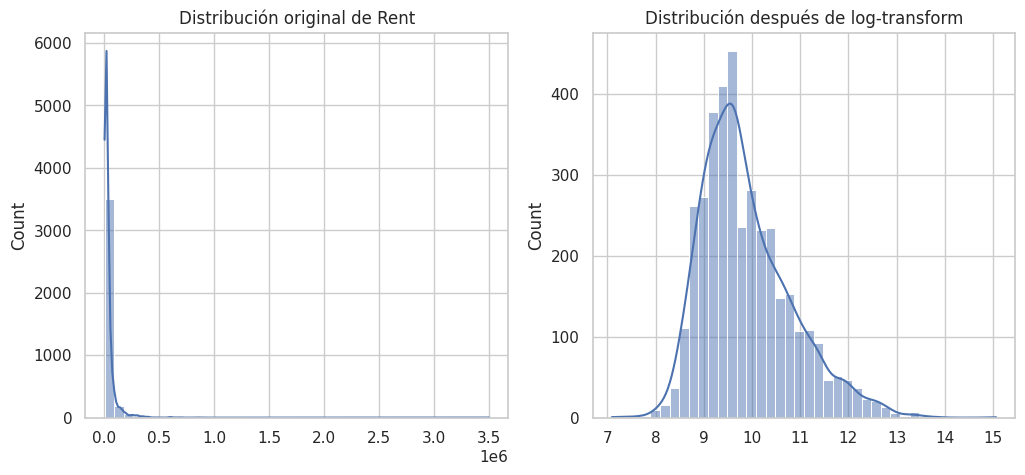

In [35]:
# ============================================================
# SUPPORT VECTOR REGRESSION (SVR) CON LOG-TRANSFORM
# ============================================================

"""
SVR puede verse afectado por distribuciones altamente asimétricas
y presencia de valores extremos.

En datasets de precios, como el valor de arriendo, suele existir
una cola larga de propiedades muy costosas que afectan el aprendizaje.

Por esta razón se aplica una transformación logarítmica sobre
la variable objetivo (Rent) antes del entrenamiento.
"""

from sklearn.svm import SVR

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# TRANSFORMACIÓN LOGARÍTMICA DEL TARGET
# ============================================================

"""
log1p(x) aplica:

log(1 + x)

Esto evita problemas con valores iguales a cero
y reduce la asimetría de la distribución.
"""

y_train_log = np.log1p(y_train)

y_test_log = np.log1p(y_test)

# ============================================================
# VISUALIZACIÓN DE LA TRANSFORMACIÓN
# ============================================================

plt.figure(figsize=(12,5))

# Distribución original
plt.subplot(1,2,1)

sns.histplot(
    y_train,
    bins=40,
    kde=True
)

plt.title("Distribución original de Rent")

# Distribución transformada
plt.subplot(1,2,2)

sns.histplot(
    y_train_log,
    bins=40,
    kde=True
)

plt.title("Distribución después de log-transform")

plt.show()

In [36]:
# ============================================================
# DEFINICIÓN DE HIPERPARÁMETROS
# ============================================================
param_grid = {

    "C": [
        1,
        10,
        50,
        100,
        500,
        1000
    ],

    "gamma": [
        "scale",
        "auto",
        1,
        0.1,
        0.01,
        0.001,
        0.0001
    ],

    "epsilon": [
        0.01,
        0.1,
        1,
        5,
        10
    ]
}

svr = SVR(kernel="rbf")

# ============================================================
# GRID SEARCH CON VALIDACIÓN CRUZADA
# ============================================================

grid = GridSearchCV(

    estimator=svr,

    param_grid=param_grid,

    cv=5,

    scoring="neg_mean_absolute_error",

    n_jobs=-1,

    verbose=1
)

# ============================================================
# ENTRENAMIENTO DEL MODELO
# ============================================================
grid.fit(
    X_train_scaled,
    y_train_log
)

# ============================================================
# MEJORES HIPERPARÁMETROS
# ============================================================

print("\nMEJORES HIPERPARÁMETROS")

print("-" * 40)

print(grid.best_params_)

# ============================================================
# INTERVALOS DE CONFIANZA
# ============================================================

mae_folds_svr = [

    -grid.cv_results_[f"split{i}_test_score"][
        grid.best_index_
    ]

    for i in range(5)
]

mae_mean_svr, mae_ci_svr = (
    intervalo_confianza_95(mae_folds_svr)
)

print("\nINTERVALOS DE CONFIANZA")

print("-" * 40)

print("MAE promedio:", mae_mean_svr)

print("IC95% MAE:", mae_ci_svr)

# ============================================================
# MEJOR MODELO
# ============================================================

best_svr = grid.best_estimator_

# ============================================================
# PREDICCIONES
# ============================================================

y_pred_log = best_svr.predict(X_test_scaled)

# Regresar a escala original
y_pred_svr = np.expm1(y_pred_log)

Fitting 5 folds for each of 210 candidates, totalling 1050 fits

MEJORES HIPERPARÁMETROS
----------------------------------------
{'C': 10, 'epsilon': 0.1, 'gamma': 0.01}

INTERVALOS DE CONFIANZA
----------------------------------------
MAE promedio: 0.28586118641846825
IC95% MAE: (np.float64(0.2709394601236458), np.float64(0.3007829127132907))


MÉTRICAS FINALES

In [37]:

# ============================================================
# MÉTRICAS FINALES
# ============================================================

mae_svr = mean_absolute_error(
    y_test,
    y_pred_svr
)

rmse_svr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_svr
    )
)

r2_svr = r2_score(
    y_test,
    y_pred_svr
)

# ============================================================
# RESULTADOS FINALES
# ============================================================

print("\nRESULTADOS SOBRE TEST")

print("-" * 40)

print("MAE:", mae_svr)

print("RMSE:", rmse_svr)

print("R²:", r2_svr)


RESULTADOS SOBRE TEST
----------------------------------------
MAE: 10273.92542483707
RMSE: 26461.494022974803
R²: 0.824305226977732


VALORES REALES VS PREDICHOS

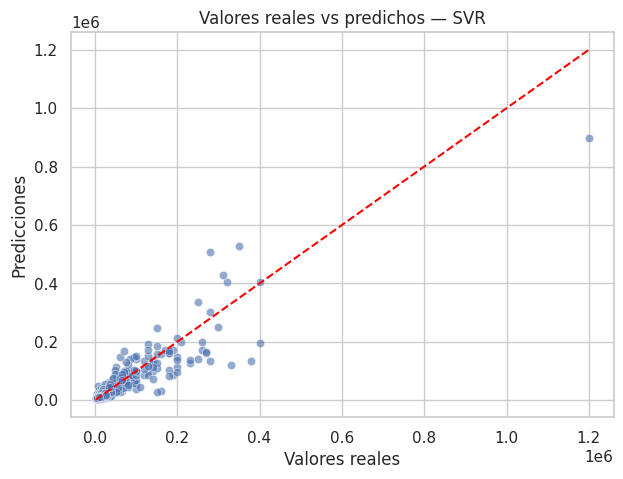

In [38]:
# ============================================================
# VALORES REALES VS PREDICHOS
# ============================================================

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_test,
    y=y_pred_svr,
    alpha=0.6
)

# Línea ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title("Valores reales vs predichos — SVR")

plt.xlabel("Valores reales")

plt.ylabel("Predicciones")

plt.show()

ANÁLISIS DE RESIDUOS

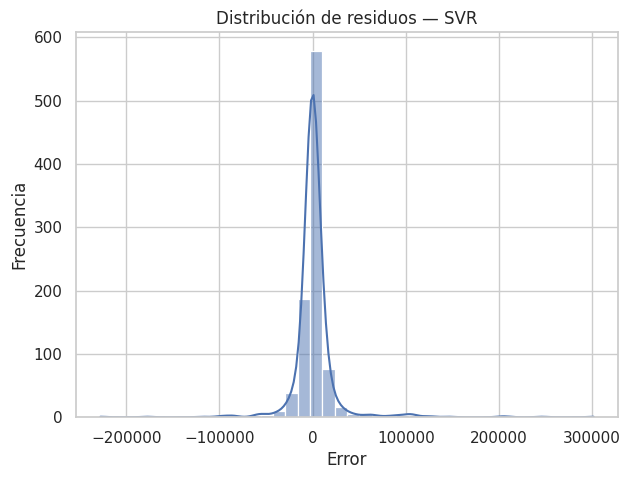

,Modelo,MAE,RMSE,R²
0,SVR con Log-Transform,10273.925425,26461.494023,0.824305


,Modelo,MAE,RMSE,R2
0,Linear Regression,20923.399307,42633.577249,0.543928
1,Decision Tree,11901.488421,33457.648806,0.719120
2,KNN,13798.869158,42808.969409,0.540167
3,SVR + Log,10273.925425,26461.494023,0.824305


In [39]:
# ============================================================
# ANÁLISIS DE RESIDUOS
# ============================================================


residuos = y_test - y_pred_svr

plt.figure(figsize=(7,5))

sns.histplot(
    residuos,
    bins=40,
    kde=True
)

plt.title("Distribución de residuos — SVR")

plt.xlabel("Error")

plt.ylabel("Frecuencia")

plt.show()

# ============================================================
# TABLA RESUMEN
# ============================================================

resultados_svr = pd.DataFrame({

    "Modelo": ["SVR con Log-Transform"],

    "MAE": [mae_svr],

    "RMSE": [rmse_svr],

    "R²": [r2_svr]
})

display(resultados_svr)

# ============================================================
# GUARDAR RESULTADOS
# ============================================================

# Crear lista si no existe
try:
    resultados_modelos
except NameError:
    resultados_modelos = []

# Guardar métricas
resultados_modelos.append({

    "Modelo": "SVR + Log",

    "MAE": mae_svr,

    "RMSE": rmse_svr,

    "R2": r2_svr
})

# Mostrar tabla acumulada
pd.DataFrame(resultados_modelos)

##XGBoost
es un algoritmo ensemble basado en árboles de decisión que utiliza técnicas de boosting para mejorar progresivamente el desempeño del modelo.

A diferencia de un único árbol de decisión, XGBoost construye múltiples árboles secuenciales donde cada nuevo árbol intenta corregir los errores cometidos por los anteriores.

Este algoritmo es ampliamente utilizado en problemas de datos tabulares debido a:

su alta capacidad predictiva,
manejo de relaciones no lineales,
resistencia al overfitting,
y eficiencia computacional.

Para optimizar el modelo, se realiza búsqueda de hiperparámetros mediante GridSearchCV, evaluando distintas configuraciones relacionadas con la complejidad y capacidad de generalización del modelo.

In [40]:
# ============================================================
# XGBOOST REGRESSOR
# ============================================================

# Instalar librería
!pip install xgboost

from xgboost import XGBRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# DEFINICIÓN DE HIPERPARÁMETROS
# ============================================================

param_grid = {

    "n_estimators": [100, 300],

    "max_depth": [3, 5, 7],

    "learning_rate": [0.05, 0.1],

    "subsample": [0.8, 1.0],

    "colsample_bytree": [0.8, 1.0],

    "gamma": [0, 1]
}

# ============================================================
# DEFINICIÓN DEL MODELO
# ============================================================

xgb = XGBRegressor(

    objective="reg:squarederror",

    eval_metric="mae",

    random_state=42
)

# ============================================================
# GRID SEARCH CON VALIDACIÓN CRUZADA
# ============================================================

grid_xgb = GridSearchCV(

    estimator=xgb,

    param_grid=param_grid,

    scoring="neg_mean_absolute_error",

    cv=5,

    n_jobs=-1,

    verbose=1
)

# ============================================================
# ENTRENAMIENTO DEL MODELO
# ============================================================

grid_xgb.fit(X_train, y_train)

# ============================================================
# MEJORES HIPERPARÁMETROS
# ============================================================

print("Mejores parámetros XGBoost:")

print(grid_xgb.best_params_)

# ============================================================
# INTERVALOS DE CONFIANZA
# ============================================================

# Extraer MAE de cada fold
mae_folds_xgb = [

    -grid_xgb.cv_results_[f"split{i}_test_score"][
        grid_xgb.best_index_
    ]

    for i in range(5)
]

# Calcular intervalo de confianza
mae_mean_xgb, mae_ci_xgb = (
    intervalo_confianza_95(mae_folds_xgb)
)

# Mostrar resultados
print("\nINTERVALOS DE CONFIANZA")
print("-" * 40)

print("XGBoost - MAE promedio:", mae_mean_xgb)

print("XGBoost - IC95% MAE:", mae_ci_xgb)



Fitting 5 folds for each of 96 candidates, totalling 480 fits
Mejores parámetros XGBoost:
{'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}

INTERVALOS DE CONFIANZA
----------------------------------------
XGBoost - MAE promedio: 13870.97578125
XGBoost - IC95% MAE: (np.float64(11960.491537545524), np.float64(15781.460024954475))


MEJOR MODELO

In [41]:
# ============================================================
# MEJOR MODELO
# ============================================================

best_xgb = grid_xgb.best_estimator_

# ============================================================
# PREDICCIONES SOBRE TEST
# ============================================================

y_pred_xgb = best_xgb.predict(X_test)

# ============================================================
# MÉTRICAS FINALES
# ============================================================

mae_xgb = mean_absolute_error(
    y_test,
    y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)

r2_xgb = r2_score(
    y_test,
    y_pred_xgb
)

# ============================================================
# RESULTADOS FINALES
# ============================================================

print("\nRESULTADOS SOBRE TEST")
print("-" * 40)

print("MAE final XGBoost:", mae_xgb)

print("RMSE final XGBoost:", rmse_xgb)

print("R² final XGBoost:", r2_xgb)




RESULTADOS SOBRE TEST
----------------------------------------
MAE final XGBoost: 12501.3408203125
RMSE final XGBoost: 41797.37790818941
R² final XGBoost: 0.5616427659988403


VALORES REALES VS PREDICHOS

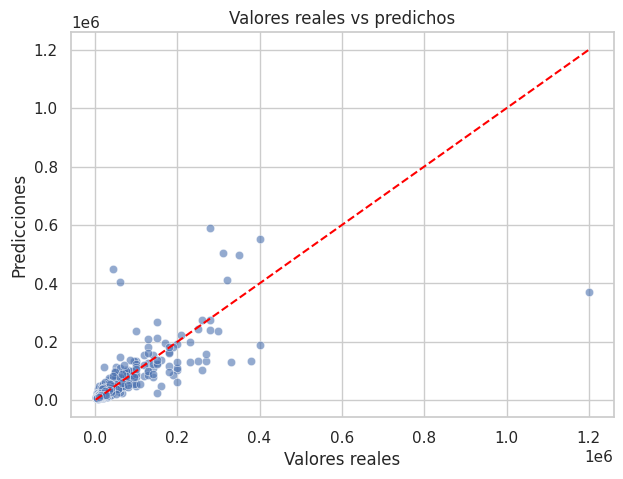

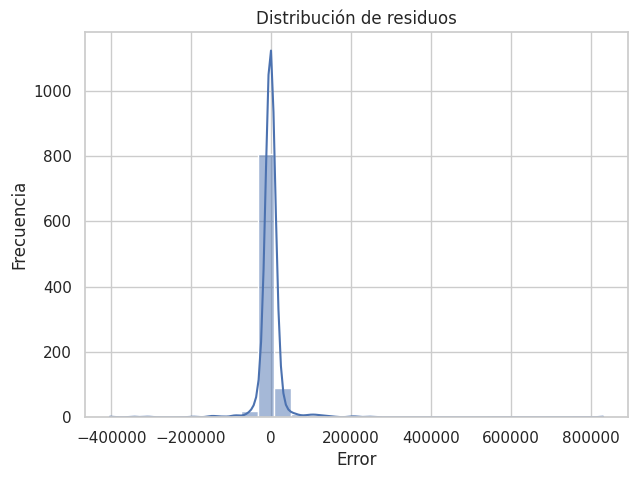

In [42]:
# ============================================================
# VALORES REALES VS PREDICHOS
# ============================================================

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_test,
    y=y_pred_xgb,
    alpha=0.6
)

# Línea ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title("Valores reales vs predichos")

plt.xlabel("Valores reales")

plt.ylabel("Predicciones")

plt.show()

# ============================================================
# ANÁLISIS DE RESIDUOS
# ============================================================

# Calcular residuos
residuos_xgb = y_test - y_pred_xgb

plt.figure(figsize=(7,5))

sns.histplot(
    residuos_xgb,
    bins=30,
    kde=True
)

plt.title("Distribución de residuos")

plt.xlabel("Error")

plt.ylabel("Frecuencia")

plt.show()



IMPORTANCIA DE VARIABLES

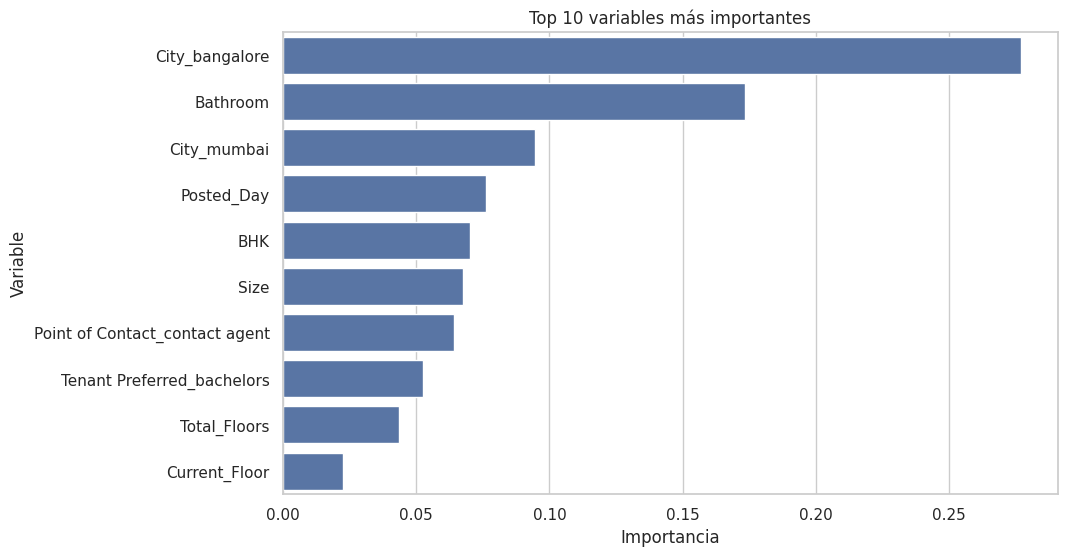

,Modelo,MAE,RMSE,R2
0,Linear Regression,20923.399307,42633.577249,0.543928
1,Decision Tree,11901.488421,33457.648806,0.719120
2,KNN,13798.869158,42808.969409,0.540167
3,SVR + Log,10273.925425,26461.494023,0.824305
4,XGBoost,12501.340820,41797.377908,0.561643


In [43]:
# ============================================================
# IMPORTANCIA DE VARIABLES
# ============================================================

# Obtener importancia de variables
importancias_xgb = pd.DataFrame({

    "Variable": X_train.columns,

    "Importancia": best_xgb.feature_importances_
})

# Ordenar variables
importancias_xgb = importancias_xgb.sort_values(
    by="Importancia",
    ascending=False
)

# Graficar top 10
plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias_xgb.head(10),
    x="Importancia",
    y="Variable"
)

plt.title("Top 10 variables más importantes")

plt.show()

# ============================================================
# GUARDAR RESULTADOS
# ============================================================

# Crear lista si no existe
try:
    resultados_modelos
except NameError:
    resultados_modelos = []

# Guardar métricas
resultados_modelos.append({

    "Modelo": "XGBoost",

    "MAE": mae_xgb,

    "RMSE": rmse_xgb,

    "R2": r2_xgb
})

# Mostrar tabla acumulada
pd.DataFrame(resultados_modelos)

##Red Neuronal
Las redes neuronales artificiales son modelos inspirados en el funcionamiento del cerebro humano, capaces de aprender relaciones complejas y no lineales entre las variables de entrada y la variable objetivo.

En este proyecto se utiliza un MLPRegressor (Multi-Layer Perceptron), el cual está compuesto por múltiples capas de neuronas conectadas entre sí.

El modelo aprende ajustando pesos internos mediante procesos iterativos de optimización, permitiendo capturar patrones complejos presentes en los datos inmobiliarios.

Debido a que las redes neuronales son sensibles a la escala de las variables, es necesario trabajar con datos previamente normalizados o escalados.

Para optimizar el desempeño del modelo, se realiza búsqueda de hiperparámetros utilizando GridSearchCV.

In [44]:
# ============================================================
# RED NEURONAL (MLP REGRESSOR)
# ============================================================

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# DEFINICIÓN DE HIPERPARÁMETROS
# ============================================================

param_grid = {

    "hidden_layer_sizes": [

        (50,),
        (100,),
        (50,50),
        (100,50)
    ],

    "activation": [

        "relu",
        "tanh"
    ],

    "solver": [
        "adam"
    ],

    "learning_rate_init": [

        0.001,
        0.01
    ],

    "alpha": [

        0.0001,
        0.001,
        0.01
    ]
}

# ============================================================
# DEFINICIÓN DEL MODELO
# ============================================================

mlp = MLPRegressor(

    max_iter=500,

    early_stopping=True,

    n_iter_no_change=10,

    tol=1e-4,

    random_state=42
)

# ============================================================
# GRID SEARCH CON VALIDACIÓN CRUZADA
# ============================================================

grid_mlp = GridSearchCV(

    estimator=mlp,

    param_grid=param_grid,

    scoring="neg_mean_absolute_error",

    cv=5,

    n_jobs=-1,

    verbose=1
)

# ============================================================
# ENTRENAMIENTO DEL MODELO
# ============================================================

grid_mlp.fit(X_train_scaled, y_train)

# ============================================================
# MEJORES HIPERPARÁMETROS
# ============================================================

print("Mejores hiperparámetros encontrados:")

print(grid_mlp.best_params_)

# ============================================================
# INTERVALOS DE CONFIANZA
# ============================================================

# Extraer MAE de cada fold
mae_folds_mlp = [

    -grid_mlp.cv_results_[f"split{i}_test_score"][
        grid_mlp.best_index_
    ]

    for i in range(5)
]

# Calcular intervalo de confianza
mae_mean_mlp, mae_ci_mlp = (
    intervalo_confianza_95(mae_folds_mlp)
)

# Mostrar resultados
print("\nINTERVALOS DE CONFIANZA")
print("-" * 40)

print("MLP - MAE promedio:", mae_mean_mlp)

print("MLP - IC95% MAE:", mae_ci_mlp)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores hiperparámetros encontrados:
{'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.01, 'solver': 'adam'}

INTERVALOS DE CONFIANZA
----------------------------------------
MLP - MAE promedio: 15731.54533597824
MLP - IC95% MAE: (np.float64(12901.49570160076), np.float64(18561.594970355723))


MEJOR MODELO

In [45]:
# ============================================================
# MEJOR MODELO
# ============================================================

best_mlp = grid_mlp.best_estimator_

# ============================================================
# PREDICCIONES SOBRE TEST
# ============================================================

y_pred_mlp = best_mlp.predict(X_test_scaled)

# ============================================================
# MÉTRICAS FINALES
# ============================================================

mae_mlp = mean_absolute_error(
    y_test,
    y_pred_mlp
)

rmse_mlp = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_mlp
    )
)

r2_mlp = r2_score(
    y_test,
    y_pred_mlp
)

# ============================================================
# RESULTADOS FINALES
# ============================================================

print("\nRESULTADOS SOBRE TEST")
print("-" * 40)

print("MAE MLP:", mae_mlp)

print("RMSE MLP:", rmse_mlp)

print("R² MLP:", r2_mlp)


RESULTADOS SOBRE TEST
----------------------------------------
MAE MLP: 16858.46938942606
RMSE MLP: 40944.49327201816
R² MLP: 0.5793497796362836


VALORES REALES VS PREDICHOS

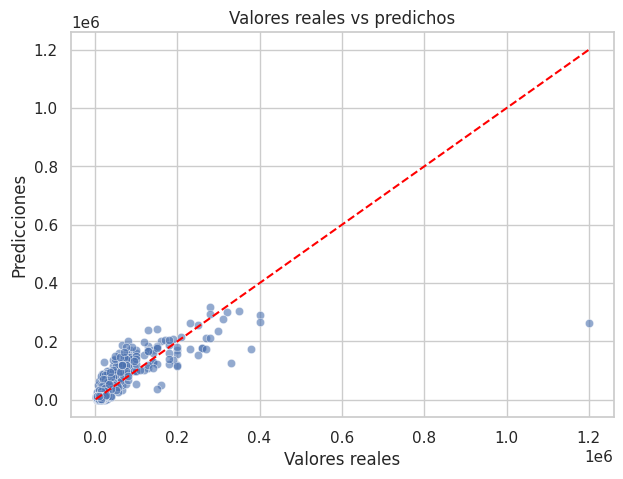

In [46]:
# ============================================================
# VALORES REALES VS PREDICHOS
# ============================================================

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_test,
    y=y_pred_mlp,
    alpha=0.6
)

# Línea ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title("Valores reales vs predichos")

plt.xlabel("Valores reales")

plt.ylabel("Predicciones")

plt.show()


ANÁLISIS DE RESIDUOS

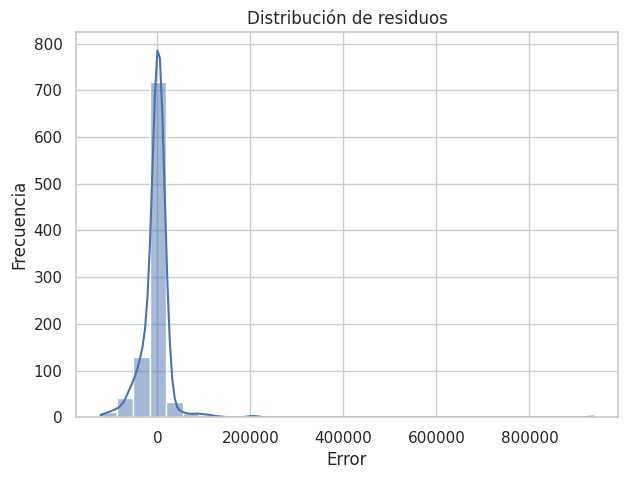

In [47]:
# ============================================================
# ANÁLISIS DE RESIDUOS
# ============================================================

# Calcular residuos
residuos_mlp = y_test - y_pred_mlp

plt.figure(figsize=(7,5))

sns.histplot(
    residuos_mlp,
    bins=30,
    kde=True
)

plt.title("Distribución de residuos")

plt.xlabel("Error")

plt.ylabel("Frecuencia")

plt.show()

CURVA DE PÉRDIDA

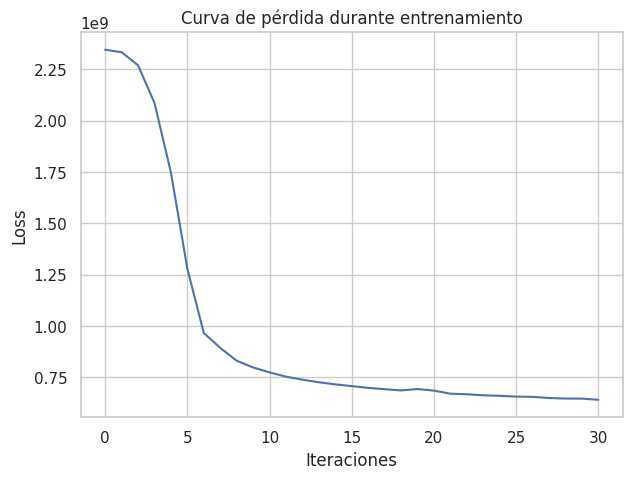

In [48]:
# ============================================================
# CURVA DE PÉRDIDA
# ============================================================

# Visualizar convergencia del entrenamiento
plt.figure(figsize=(7,5))

plt.plot(best_mlp.loss_curve_)

plt.title("Curva de pérdida durante entrenamiento")

plt.xlabel("Iteraciones")

plt.ylabel("Loss")

plt.show()

GUARDAR RESULTADOS

In [49]:
# ============================================================
# GUARDAR RESULTADOS
# ============================================================

# Crear lista si no existe
try:
    resultados_modelos
except NameError:
    resultados_modelos = []

# Guardar métricas
resultados_modelos.append({

    "Modelo": "MLP Regressor",

    "MAE": mae_mlp,

    "RMSE": rmse_mlp,

    "R2": r2_mlp
})

# Mostrar tabla acumulada
pd.DataFrame(resultados_modelos)

,Modelo,MAE,RMSE,R2
0,Linear Regression,20923.399307,42633.577249,0.543928
1,Decision Tree,11901.488421,33457.648806,0.719120
2,KNN,13798.869158,42808.969409,0.540167
3,SVR + Log,10273.925425,26461.494023,0.824305
4,XGBoost,12501.340820,41797.377908,0.561643
5,MLP Regressor,16858.469389,40944.493272,0.579350


#Evaluación de Resultados
En esta sección se comparan los distintos modelos de regresión entrenados utilizando métricas de desempeño como:

MAE (Mean Absolute Error),
RMSE (Root Mean Squared Error),
y R
2
 (coeficiente de determinación).

Además, se analiza la estabilidad de los modelos mediante intervalos de confianza y se estudia el comportamiento del modelo con mejor desempeño.


RESULTADOS FINALES
--------------------------------------------------


,Modelo,MAE,RMSE,R2
3,SVR + Log,10273.925425,26461.494023,0.824305
1,Decision Tree,11901.488421,33457.648806,0.719120
4,XGBoost,12501.340820,41797.377908,0.561643
2,KNN,13798.869158,42808.969409,0.540167
5,MLP Regressor,16858.469389,40944.493272,0.579350
0,Linear Regression,20923.399307,42633.577249,0.543928


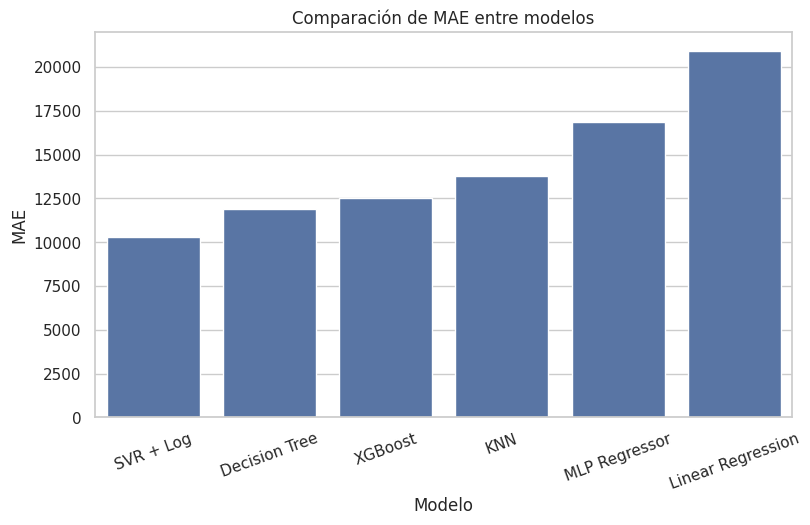

In [50]:
# ============================================================
# EVALUACIÓN DE RESULTADOS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ============================================================
# TABLA FINAL DE RESULTADOS
# ============================================================

# Convertir resultados a DataFrame
resultados_df = pd.DataFrame(resultados_modelos)

# Ordenar por MAE
resultados_df = resultados_df.sort_values(
    by="MAE"
)

print("\nRESULTADOS FINALES")
print("-" * 50)

display(resultados_df)

# ============================================================
# COMPARACIÓN DE MAE
# ============================================================

plt.figure(figsize=(9,5))

sns.barplot(
    data=resultados_df,
    x="Modelo",
    y="MAE"
)

plt.title("Comparación de MAE entre modelos")

plt.ylabel("MAE")

plt.xticks(rotation=20)

plt.show()

COMPARACIÓN DE RMSE

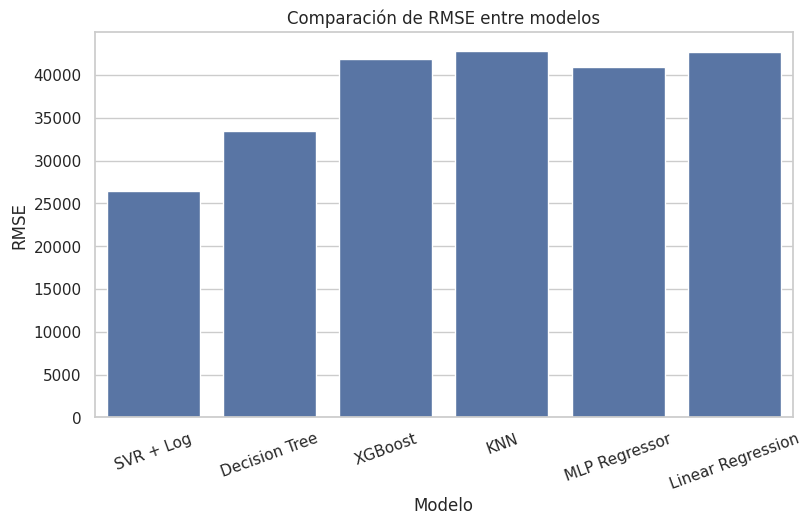

In [51]:
# ============================================================
# COMPARACIÓN DE RMSE
# ============================================================

plt.figure(figsize=(9,5))

sns.barplot(
    data=resultados_df,
    x="Modelo",
    y="RMSE"
)

plt.title("Comparación de RMSE entre modelos")

plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

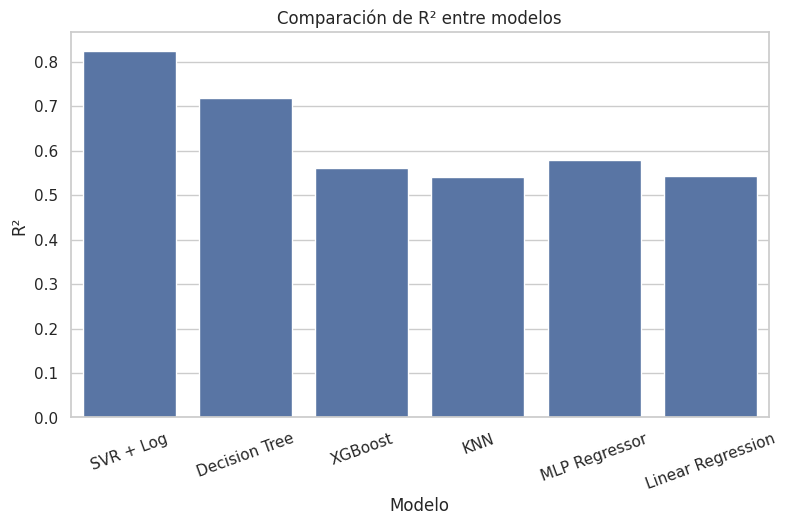

In [52]:
# ============================================================
# COMPARACIÓN DE R²
# ============================================================

plt.figure(figsize=(9,5))

sns.barplot(
    data=resultados_df,
    x="Modelo",
    y="R2"
)

plt.title("Comparación de R² entre modelos")

plt.ylabel("R²")

plt.xticks(rotation=20)

plt.show()

INTERVALOS DE CONFIANZA

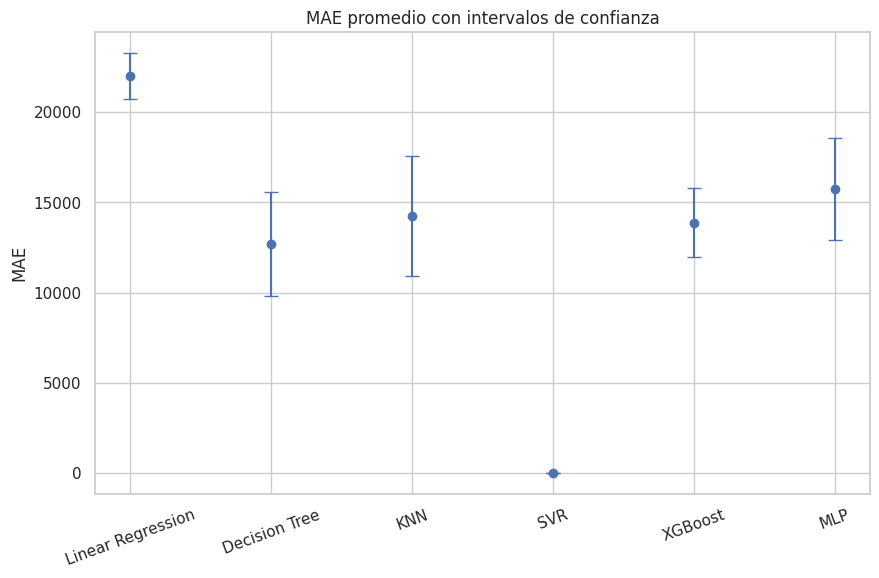

In [53]:
# ============================================================
# INTERVALOS DE CONFIANZA
# ============================================================

# Crear resumen de intervalos
intervalos_df = pd.DataFrame({

    "Modelo": [

        "Linear Regression",
        "Decision Tree",
        "KNN",
        "SVR",
        "XGBoost",
        "MLP"
    ],

    "MAE Promedio": [

        mae_mean,
        mae_mean_dt,
        mae_mean_knn,
        mae_mean_svr,
        mae_mean_xgb,
        mae_mean_mlp
    ],

    "IC Inferior": [

        mae_ci[0],
        mae_ci_dt[0],
        mae_ci_knn[0],
        mae_ci_svr[0],
        mae_ci_xgb[0],
        mae_ci_mlp[0]
    ],

    "IC Superior": [

        mae_ci[1],
        mae_ci_dt[1],
        mae_ci_knn[1],
        mae_ci_svr[1],
        mae_ci_xgb[1],
        mae_ci_mlp[1]
    ]
})

# Barras de error
plt.figure(figsize=(10,6))

plt.errorbar(

    intervalos_df["Modelo"],

    intervalos_df["MAE Promedio"],

    yerr=[

        intervalos_df["MAE Promedio"] - intervalos_df["IC Inferior"],

        intervalos_df["IC Superior"] - intervalos_df["MAE Promedio"]
    ],

    fmt='o',

    capsize=5
)

plt.title("MAE promedio con intervalos de confianza")

plt.ylabel("MAE")

plt.xticks(rotation=20)

plt.show()

MEJOR MODELO


MEJOR MODELO
----------------------------------------
Modelo       SVR + Log
MAE       10273.925425
RMSE      26461.494023
R2            0.824305
Name: 3, dtype: object


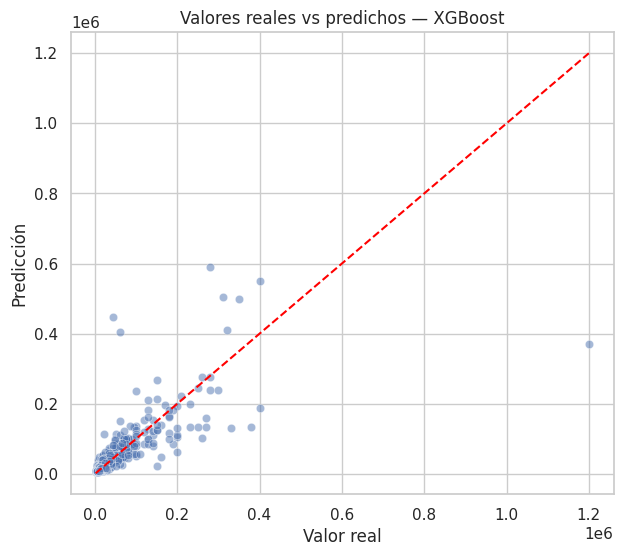

In [54]:
# ============================================================
# MEJOR MODELO
# ============================================================

# Obtener mejor modelo según MAE
mejor_modelo = resultados_df.iloc[0]

print("\nMEJOR MODELO")
print("-" * 40)

print(mejor_modelo)

# ============================================================
# REAL VS PREDICHO (XGBOOST)
# ============================================================

plt.figure(figsize=(7,6))

sns.scatterplot(
    x=y_test,
    y=y_pred_xgb,
    alpha=0.5
)

# Línea ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title("Valores reales vs predichos — XGBoost")

plt.xlabel("Valor real")

plt.ylabel("Predicción")

plt.show()

IMPORTANCIA DE VARIABLES

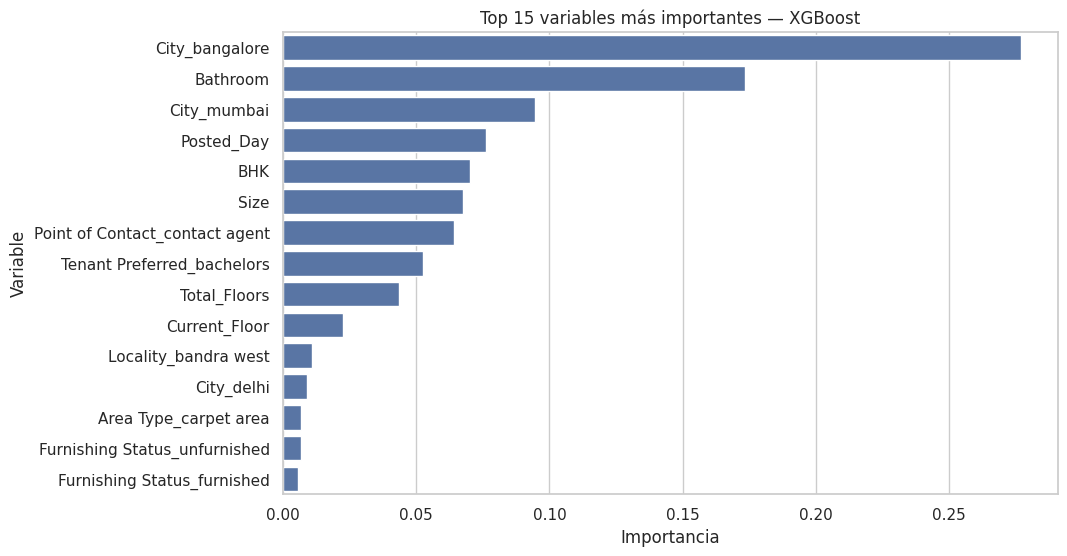

In [55]:
# ============================================================
# IMPORTANCIA DE VARIABLES
# ============================================================

importancias_xgb = pd.DataFrame({

    "Variable": X_train.columns,

    "Importancia": best_xgb.feature_importances_
})

# Ordenar
importancias_xgb = importancias_xgb.sort_values(
    by="Importancia",
    ascending=False
)

# Mostrar top 15
plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias_xgb.head(15),
    x="Importancia",
    y="Variable"
)

plt.title("Top 15 variables más importantes — XGBoost")

plt.show()

#Reducción de Dimensión
Debido a la alta dimensionalidad generada por la codificación de variables categóricas, se aplicaron técnicas de reducción de dimensión con el objetivo de:

disminuir ruido,
compactar información relevante,
mejorar la representación de los datos,
y analizar posibles agrupamientos naturales dentro del dataset.

Se utilizaron dos enfoques principales:

PCA (Principal Component Analysis): técnica lineal que busca conservar la mayor varianza posible.
UMAP (Uniform Manifold Approximation and Projection): técnica no lineal utilizada principalmente para visualización y detección de clusters.

Posteriormente, se reentrenaron modelos sensibles a la dimensionalidad para evaluar el impacto de estas transformaciones sobre el desempeño predictivo.

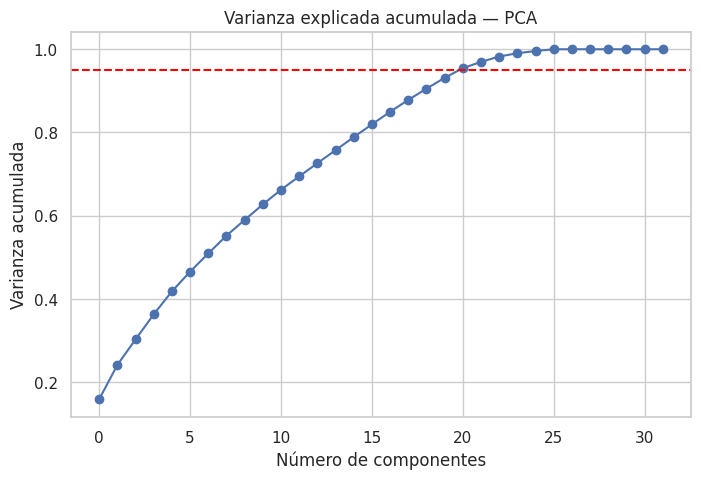

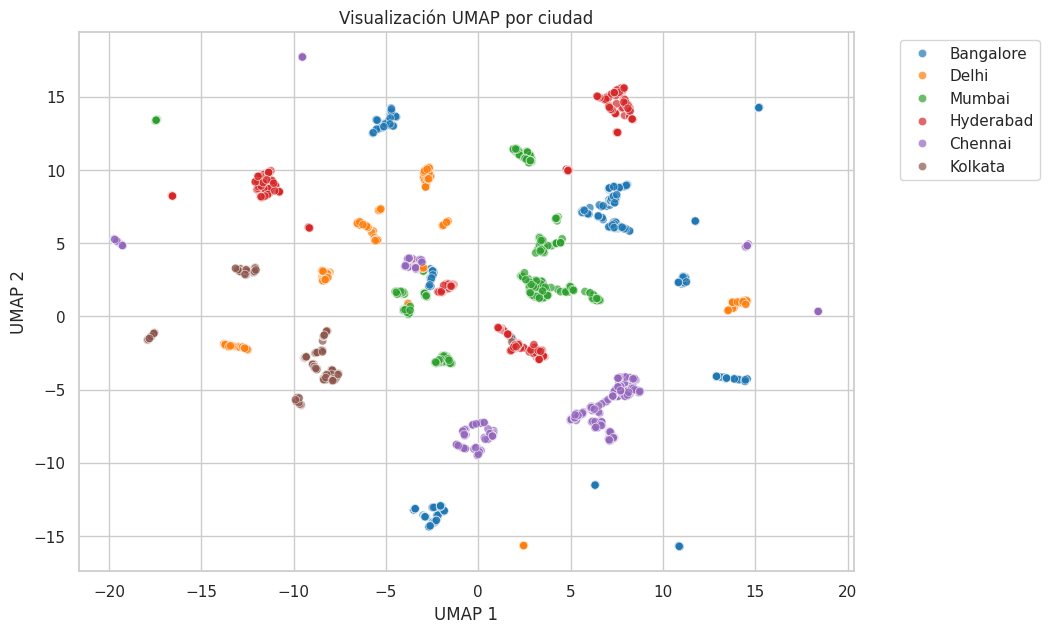

In [56]:
# ============================================================
# REDUCCIÓN DE DIMENSIÓN
# ============================================================

!pip install umap-learn

import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")

# ============================================================
# ANÁLISIS DE VARIANZA EXPLICADA (PCA)
# ============================================================

"""
Antes de seleccionar el número de componentes principales,
se analiza cuánta varianza acumulada conserva el modelo PCA.
"""

scaler = StandardScaler()

X_train_scaled_temp = scaler.fit_transform(X_train)

pca_temp = PCA().fit(X_train_scaled_temp)

plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(pca_temp.explained_variance_ratio_),
    marker='o'
)

plt.axhline(
    0.95,
    color='red',
    linestyle='--'
)

plt.xlabel("Número de componentes")

plt.ylabel("Varianza acumulada")

plt.title("Varianza explicada acumulada — PCA")

plt.grid(True)

plt.show()

# ============================================================
# VISUALIZACIÓN CON UMAP
# ============================================================

"""
UMAP se utiliza para visualizar posibles agrupamientos
naturales dentro del dataset.

Las muestras se colorean según la ciudad para analizar
si existen clusters asociados a la ubicación geográfica.
"""

# Reducir a 2 dimensiones para visualización
umap_visual = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap_visual = umap_visual.fit_transform(X_train_scaled_temp)

plt.figure(figsize=(10,7))

sns.scatterplot(

    x=X_umap_visual[:,0],

    y=X_umap_visual[:,1],

    hue=df.loc[X_train.index, "City"],

    palette="tab10",

    alpha=0.7
)

plt.title("Visualización UMAP por ciudad")

plt.xlabel("UMAP 1")

plt.ylabel("UMAP 2")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

##KNN con reducción mediante PCA

El algoritmo KNN depende directamente de distancias entre muestras, por lo que puede verse afectado por problemas de alta dimensionalidad.

Para evaluar el impacto de la reducción de dimensión, se aplicó PCA antes del entrenamiento del modelo, buscando compactar la información relevante y reducir ruido en los datos.


RESULTADOS KNN + PCA
MAE: 13836.290822709252
RMSE: 42023.93862081216
R²: 0.5568776795344615


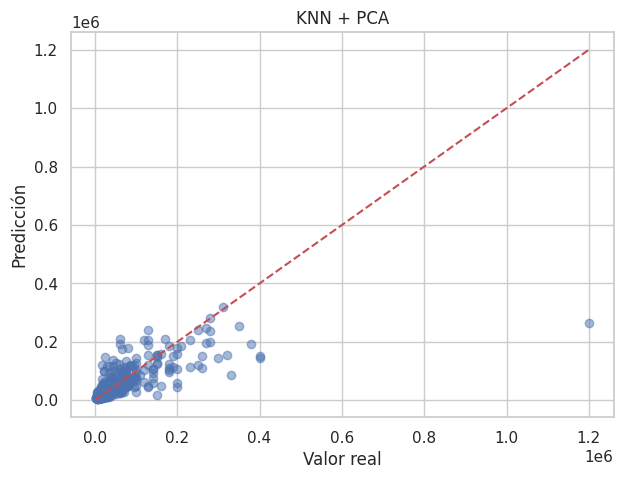

In [57]:
# ============================================================
# KNN + PCA
# ============================================================
n_components_pca = 5

pca_knn = Pipeline([

    ('scaler', StandardScaler()),

    ('pca', PCA(
        n_components=n_components_pca,
        random_state=42
    )),

    ('knn', clone(best_knn))
])

# Entrenamiento
pca_knn.fit(X_train, y_train)

# Predicciones
y_pred_knn_pca = pca_knn.predict(X_test)

# Métricas
mae_knn_pca = mean_absolute_error(
    y_test,
    y_pred_knn_pca
)

rmse_knn_pca = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_knn_pca
    )
)

r2_knn_pca = r2_score(
    y_test,
    y_pred_knn_pca
)

# Resultados
print("\n" + "="*50)
print("RESULTADOS KNN + PCA")
print("="*50)

print("MAE:", mae_knn_pca)

print("RMSE:", rmse_knn_pca)

print("R²:", r2_knn_pca)

# Gráfica
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred_knn_pca,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Valor real")

plt.ylabel("Predicción")

plt.title("KNN + PCA")

plt.show()

##KNN con reducción mediante UMAP
UMAP permite representar los datos en espacios de menor dimensión preservando relaciones locales entre muestras similares.

Debido a que KNN depende directamente de vecindades y distancias, se evaluó el desempeño del modelo utilizando embeddings generados mediante UMAP.


RESULTADOS KNN + UMAP
MAE: 17033.73377775437
RMSE: 48089.06930210999
R²: 0.4197396930682099


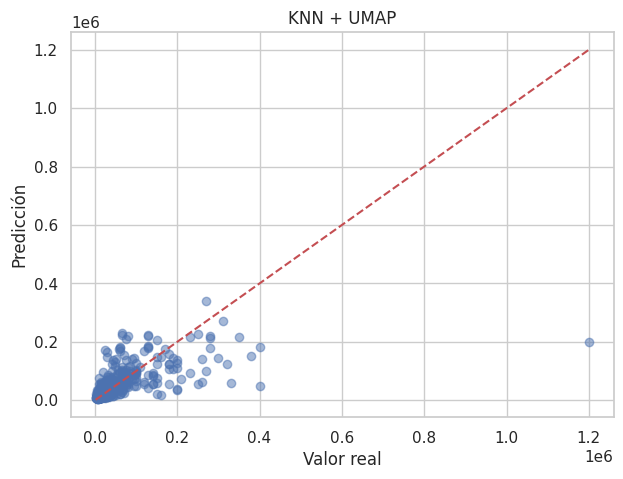

In [58]:
# ============================================================
# KNN + UMAP
# ============================================================
umap_knn = Pipeline([

    ('scaler', StandardScaler()),

    ('umap', umap.UMAP(

        n_components=5,

        n_neighbors=15,

        min_dist=0.1,

        random_state=42
    )),

    ('knn', clone(best_knn))
])

# Entrenamiento
umap_knn.fit(X_train, y_train)

# Predicciones
y_pred_knn_umap = umap_knn.predict(X_test)

# Métricas
mae_knn_umap = mean_absolute_error(
    y_test,
    y_pred_knn_umap
)

rmse_knn_umap = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_knn_umap
    )
)

r2_knn_umap = r2_score(
    y_test,
    y_pred_knn_umap
)

# Resultados
print("\n" + "="*50)
print("RESULTADOS KNN + UMAP")
print("="*50)

print("MAE:", mae_knn_umap)

print("RMSE:", rmse_knn_umap)

print("R²:", r2_knn_umap)

# Gráfica
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred_knn_umap,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Valor real")

plt.ylabel("Predicción")

plt.title("KNN + UMAP")

plt.show()

##SVR con reducción mediante PCA

El modelo SVR puede verse afectado por datasets de alta dimensionalidad debido a la complejidad geométrica del espacio de características.

Por esta razón, se utilizó PCA para compactar la información y reducir ruido antes del entrenamiento.


RESULTADOS SVR + PCA
MAE: 10626.154987408561
RMSE: 33609.85717489674
R²: 0.7165584897863192


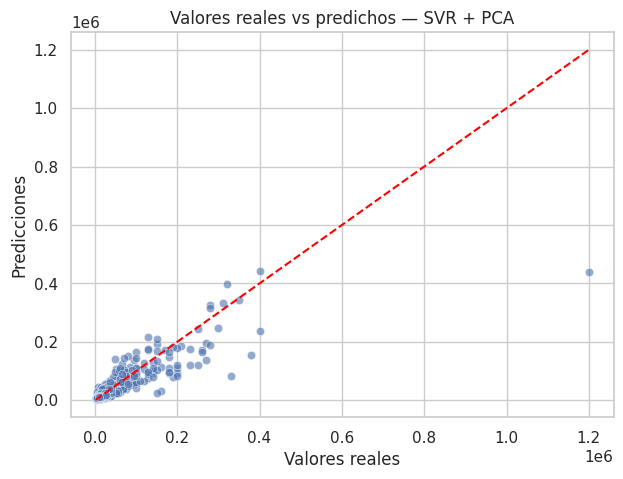

In [59]:
# ============================================================
# SVR + PCA
# ============================================================

"""
Se aplica PCA antes del entrenamiento del modelo SVR
con el objetivo de reducir dimensionalidad y compactar
la información más relevante del dataset.

Además, se mantiene la transformación logarítmica
sobre la variable objetivo para reducir asimetría
y sensibilidad a valores extremos.
"""

# ============================================================
# PIPELINE PCA + SVR
# ============================================================

pca_svr = Pipeline([

    ('scaler', StandardScaler()),

    ('pca', PCA(

        n_components=0.95,

        random_state=42
    )),

    ('svr', clone(best_svr))
])

# ============================================================
# ENTRENAMIENTO
# ============================================================

"""
El entrenamiento se realiza usando la versión
log-transformada del target.
"""

pca_svr.fit(
    X_train,
    y_train_log
)

# ============================================================
# PREDICCIONES
# ============================================================

# Predicción en escala logarítmica
y_pred_log_pca = pca_svr.predict(X_test)

# Regresar a escala original
y_pred_svr_pca = np.expm1(y_pred_log_pca)

# ============================================================
# MÉTRICAS
# ============================================================

mae_svr_pca = mean_absolute_error(
    y_test,
    y_pred_svr_pca
)

rmse_svr_pca = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_svr_pca
    )
)

r2_svr_pca = r2_score(
    y_test,
    y_pred_svr_pca
)

# ============================================================
# RESULTADOS
# ============================================================

print("\n" + "="*50)
print("RESULTADOS SVR + PCA")
print("="*50)

print("MAE:", mae_svr_pca)

print("RMSE:", rmse_svr_pca)

print("R²:", r2_svr_pca)

# ============================================================
# VISUALIZACIÓN
# ============================================================

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_test,
    y=y_pred_svr_pca,
    alpha=0.6
)

# Línea ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title("Valores reales vs predichos — SVR + PCA")

plt.xlabel("Valores reales")

plt.ylabel("Predicciones")

plt.show()

##SVR con reducción mediante UMAP

Con el objetivo de explorar representaciones no lineales de los datos, se aplicó UMAP antes del entrenamiento del modelo SVR.

Esto permite evaluar si la estructura local aprendida por UMAP mejora la capacidad predictiva del modelo.


RESULTADOS SVR + UMAP
MAE: 16760.564065988092
RMSE: 49564.82756174056
R²: 0.3835791519774622


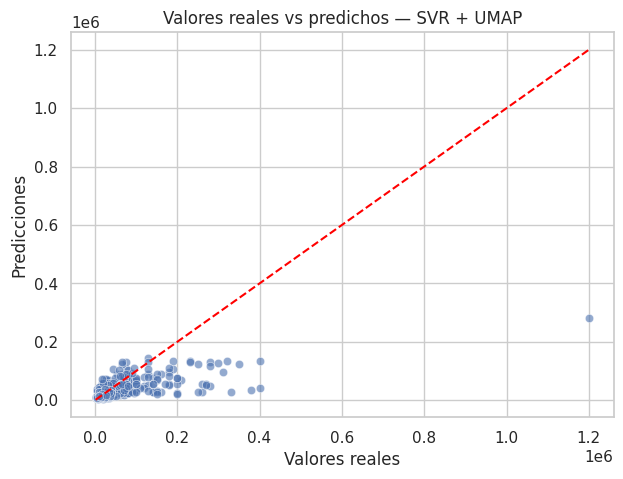

In [60]:
# ============================================================
# SVR + UMAP
# ============================================================

umap_svr = Pipeline([

    ('scaler', StandardScaler()),

    ('umap', umap.UMAP(

        n_components=33,

        n_neighbors=15,

        min_dist=0.1,

        random_state=42
    )),

    ('svr', clone(best_svr))
])

# ============================================================
# ENTRENAMIENTO
# ============================================================

"""
El modelo se entrena utilizando la versión
log-transformada del target.
"""

umap_svr.fit(
    X_train,
    y_train_log
)

# ============================================================
# PREDICCIONES
# ============================================================

# Predicción en escala logarítmica
y_pred_log_umap = umap_svr.predict(X_test)

# Regresar a escala original
y_pred_svr_umap = np.expm1(y_pred_log_umap)

# ============================================================
# MÉTRICAS
# ============================================================

mae_svr_umap = mean_absolute_error(
    y_test,
    y_pred_svr_umap
)

rmse_svr_umap = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_svr_umap
    )
)

r2_svr_umap = r2_score(
    y_test,
    y_pred_svr_umap
)

# ============================================================
# RESULTADOS
# ============================================================

print("\n" + "="*50)
print("RESULTADOS SVR + UMAP")
print("="*50)

print("MAE:", mae_svr_umap)

print("RMSE:", rmse_svr_umap)

print("R²:", r2_svr_umap)

# ============================================================
# VISUALIZACIÓN
# ============================================================

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_test,
    y=y_pred_svr_umap,
    alpha=0.6
)

# Línea ideal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title("Valores reales vs predichos — SVR + UMAP")

plt.xlabel("Valores reales")

plt.ylabel("Predicciones")

plt.show()

##TABLA FINAL COMPARATIVA

In [61]:

# ============================================================
# TABLA COMPARATIVA FINAL
# ============================================================

"""
Comparación entre los modelos originales y las versiones
entrenadas usando reducción de dimensión.
"""

comparacion_reduccion = pd.DataFrame({

    "Modelo": [

        "KNN Original",
        "KNN + PCA",
        "KNN + UMAP",

        "SVR Original",
        "SVR + PCA",
        "SVR + UMAP"
    ],

    "MAE": [

        final_mae_knn,
        mae_knn_pca,
        mae_knn_umap,

        mae,
        mae_svr_pca,
        mae_svr_umap
    ],

    "RMSE": [

        final_rmse_knn,
        rmse_knn_pca,
        rmse_knn_umap,

        rmse,
        rmse_svr_pca,
        rmse_svr_umap
    ],

    "R²": [

        final_r2_knn,
        r2_knn_pca,
        r2_knn_umap,

        r2_svr,
        r2_svr_pca,
        r2_svr_umap
    ]
})

display(comparacion_reduccion)

,Modelo,MAE,RMSE,R²
0,KNN Original,13798.869158,42808.969409,0.540167
1,KNN + PCA,13836.290823,42023.938621,0.556878
2,KNN + UMAP,17033.733778,48089.069302,0.419740
3,SVR Original,22481.622902,45741.447273,0.824305
4,SVR + PCA,10626.154987,33609.857175,0.716558
5,SVR + UMAP,16760.564066,49564.827562,0.383579


##VISUALIZACIÓN COMPARATIVA

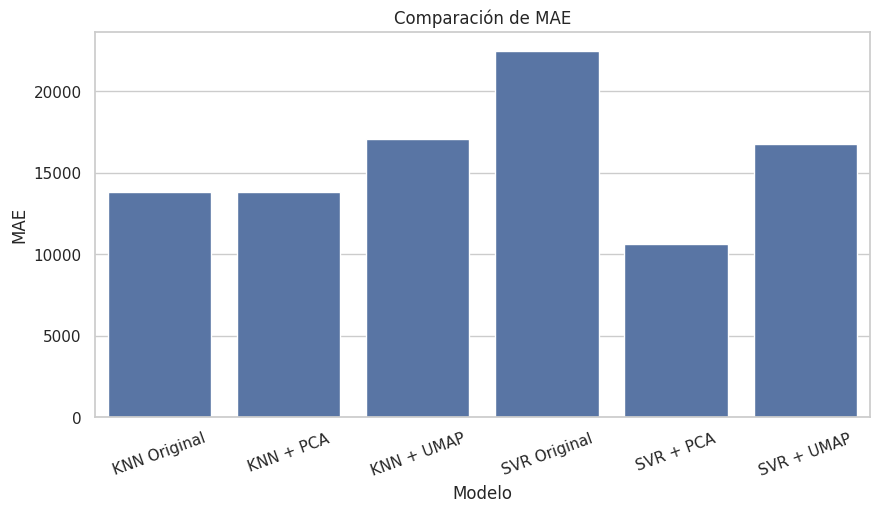

In [62]:
# ============================================================
# VISUALIZACIÓN COMPARATIVA
# ============================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=comparacion_reduccion,
    x="Modelo",
    y="MAE"
)

plt.title("Comparación de MAE")

plt.xticks(rotation=20)

plt.show()

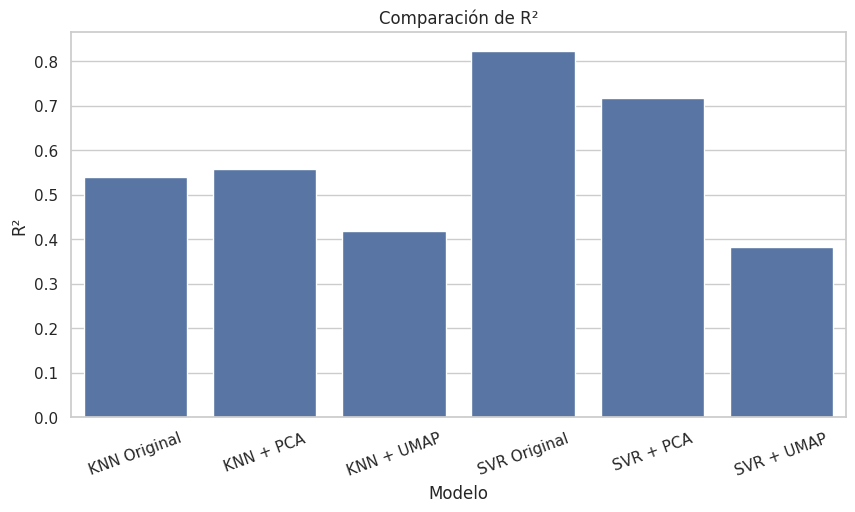

In [63]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparacion_reduccion,
    x="Modelo",
    y="R²"
)

plt.title("Comparación de R²")

plt.xticks(rotation=20)

plt.show()